# Tutorial for gwaslab

- En este tutorial, ofreceremos una breve descripción general de las funciones principales de GWASLab para el control de calidad (CC), la estandarización y la armonización de las estadísticas resumidas.

- También mostraremos las funciones de visualización, incluyendo gráficos de Manhattan, gráficos Q-Q y gráficos regionales.



## Descargar datos de muestra

- Usando un cuaderno Jupyter, primero descargamos un conjunto de datos de ejemplo.
- El conjunto de datos de muestra que utilizaremos como ejemplo (Tamaño del archivo: 40 MB)

1. Estadísticas de muestra `bbj_t2d_hm3_chr7_variants.txt.gz`: estadísticas procesadas (solo variantes de hapmap3 y región del cromosoma 7) de diabetes tipo 2 de BBJ (K. Suzuki et al., Nature Genetics. 51, 379–386 (2019)).

2. Tabla de conversión SNPID-rsID (muestra) `1kg_dbsnp151_hg19_auto_hm3_chr7_variants.txt.gz`

3. Archivo VCF de dbSNP (muestra) `b157_2564.vcf.gz`

4. Archivo VCF de referencia EAS de 1 kg (solo cromosoma 7: 126253550-128253550) `1kg_eas_hg19.chr7_126253550_128253550.vcf.gz`

In [2]:
!wget https://raw.githubusercontent.com/cloufield/gwaslab/main/examples/1_main_tutorial/sample_data.tar.gz
!tar -xvzf sample_data.tar.gz

dyld[5172]: missing symbol called
x ./sample_data/
x ./sample_data/bbj_t2d_hm3_chr7_variants.txt.gz
x ./sample_data/1kg_eas_hg19.chr7_126253550_128253550.vcf.gz
x ./sample_data/b157_2564.vcf.gz
x ./sample_data/1kg_eas_hg19.chr7_126253550_128253550.vcf.gz.tbi
x ./sample_data/1kg_dbsnp151_hg19_auto_hm3_chr7_variants.txt.gz
x ./sample_data/b157_2564.vcf.gz.tbi


## Importar el paquete gwaslab

Si instalaste gwaslab desde pip, simplemente ejecuta el comando para importar el paquete:

In [3]:
import gwaslab as gl

## Cargando datos en gwaslab Sumstats

Vamos a importar las estadísticas sumatorias sin procesar al objeto `gwaslab.Sumstats` especificando las columnas necesarias.

In [4]:
mysumstats = gl.Sumstats("./sample_data/bbj_t2d_hm3_chr7_variants.txt.gz",
             snpid="SNPID",
             chrom="CHR",
             pos="POS",
             ea="EA",
             nea="NEA",
             neaf="EAF",
             beta="BETA",
             se="SE",
             p="P",
             n="N",
             sep="\t")

2026/03/19 09:17:22 GWASLab v4.1.2 https://cloufield.github.io/gwaslab/
2026/03/19 09:17:22 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/03/19 09:17:22 Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:51:19) [Clang 19.1.7 ]
2026/03/19 09:17:22  -Top 3 inferred source formats:
2026/03/19 09:17:22    1. gwaslab [DETECTED] (score: 39.103) | 2. saige (score: 16.477) | 3. mrmega (score: 14.408)
2026/03/19 09:17:22 Start to initialize gl.Sumstats from file :./sample_data/bbj_t2d_hm3_chr7_variants.txt.gz
2026/03/19 09:17:24  -Reading columns          : POS,CHR,NEA,SE,BETA,N,SNPID,EA,EAF,P
2026/03/19 09:17:24  -Renaming columns to      : POS,CHR,NEA,SE,BETA,N,SNPID,EA,EAF,P
2026/03/19 09:17:24  -Current Dataframe shape : 1103020  x  10
2026/03/19 09:17:24  -Initiating a status column: STATUS ...
2026/03/19 09:17:24 #WARNING! Version of genomic coordinates is unknown for homo sapiens (build: 99)...
2026/03/19 09:17:24  -NEAF is specifi

## Carga mediante la especificación de una palabra clave en el libro de formato

O bien, puede especificar simplemente las palabras clave de formato que aparecen en formatbook (https://github.com/Cloufield/formatbook).

In [6]:
# mysumstats = gl.Sumstats("./sample_data/bbj_t2d_hm3_chr7_variants.txt.gz", fmt="gwaslab", verbose=True)

## Sumstats.data

Las estadísticas totales se almacenan en `Sumstats.data` como un pandas.DataFrame, puedes consultar los datos de la siguiente manera:

In [5]:
mysumstats.data

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566_G_A,1,752566,G,A,9999999,0.8422,-0.0155,0.0131,0.2350,166718
1,1:752721_A_G,1,752721,G,A,9999999,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182_A_G,1,754182,G,A,9999999,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912_C_T,1,760912,C,T,9999999,0.8425,-0.0171,0.0148,0.2480,166718
4,1:761147_T_C,1,761147,C,T,9999999,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911_A_G,X,154343911,G,A,9999999,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088_C_A,X,154379088,C,A,9999999,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836_C_T,X,154536836,C,T,9999999,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036_A_G,X,154763036,G,A,9999999,0.3686,-0.0102,0.0105,0.3302,191764


## Genoma inferido

Si no se especifica la compilación, gwaslab puede inferirla basándose en los SNP de HapMap3. Para más detalles, consulte: https://cloufield.github.io/gwaslab/InferBuild/

In [6]:
mysumstats.infer_build()

2026/03/19 09:17:56  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:17:56 Start to infer genome build version using hapmap3 SNPs ...(v4.1.2)
2026/03/19 09:17:56  -Current Dataframe shape : 1103020 x 11 ; Memory usage: 87.32 MB
2026/03/19 09:17:56 #WARNING! Data types were not fixed for : CHR 
2026/03/19 09:17:56 Start to fix chromosome notation (CHR) ...(v4.1.2)
2026/03/19 09:17:56  -Checking CHR data type...
2026/03/19 09:17:56  -Variants with standardized chromosome notation: 1100517
2026/03/19 09:17:56  -Variants with fixable chromosome notations: 2503
2026/03/19 09:17:56  -No unrecognized chromosome notations...
2026/03/19 09:17:56  -Identifying non-autosomal chromosomes : X, Y, and MT ...
2026/03/19 09:17:56  -Identified 2503 variants on sex chromosomes...
2026/03/19 09:17:56  -Standardizing first sex chromosome chromosome notations: X to 23...
2026/03/19 09:17:57  -Time taken: 0.894s
2026/03/19 09:17:57 Finished fixing chromosome notation (CHR).
2026/03/19 09:17:5

## Crear diagramas de Manhattan y diagramas Q-Q

Lo primero que probablemente querrás revisar son los gráficos de Manhattan y Q-Q para tus estadísticas descriptivas.

gwaslab realiza un control de calidad mínimo de los datos automáticamente al generar estos gráficos.

2026/03/19 09:18:10 Configured plot style for plot_mqq:mqq
2026/03/19 09:18:10 Starting Manhattan-QQ plot creation (Version v4.1.2)
2026/03/19 09:18:10  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:18:10  - Genomic coordinates version: 19 ...
2026/03/19 09:18:10  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:18:10  - Input sumstats contains 1103020 variants...
2026/03/19 09:18:10  - Manhattan-QQ plot layout mode selected: mqq
2026/03/19 09:18:11 Finished loading specified columns from the statistics
2026/03/19 09:18:11 Start data conversion and sanity check:
2026/03/19 09:18:11  -Sumstats P values are being converted to -log10(P)...
2026/03/19 09:18:12  -Converting data above cut line...
2026/03/19 09:18:12  -Maximum -log10(P) value is 152.39254497678533 .
2026/03/19 09:18:12 Finished data conversion and sanity check.
2026/03/19 09:18:12 Start to create Manhattan-QQ plot with 1103020 variants...
2026/03/19 09:18:14  -Creating background pl

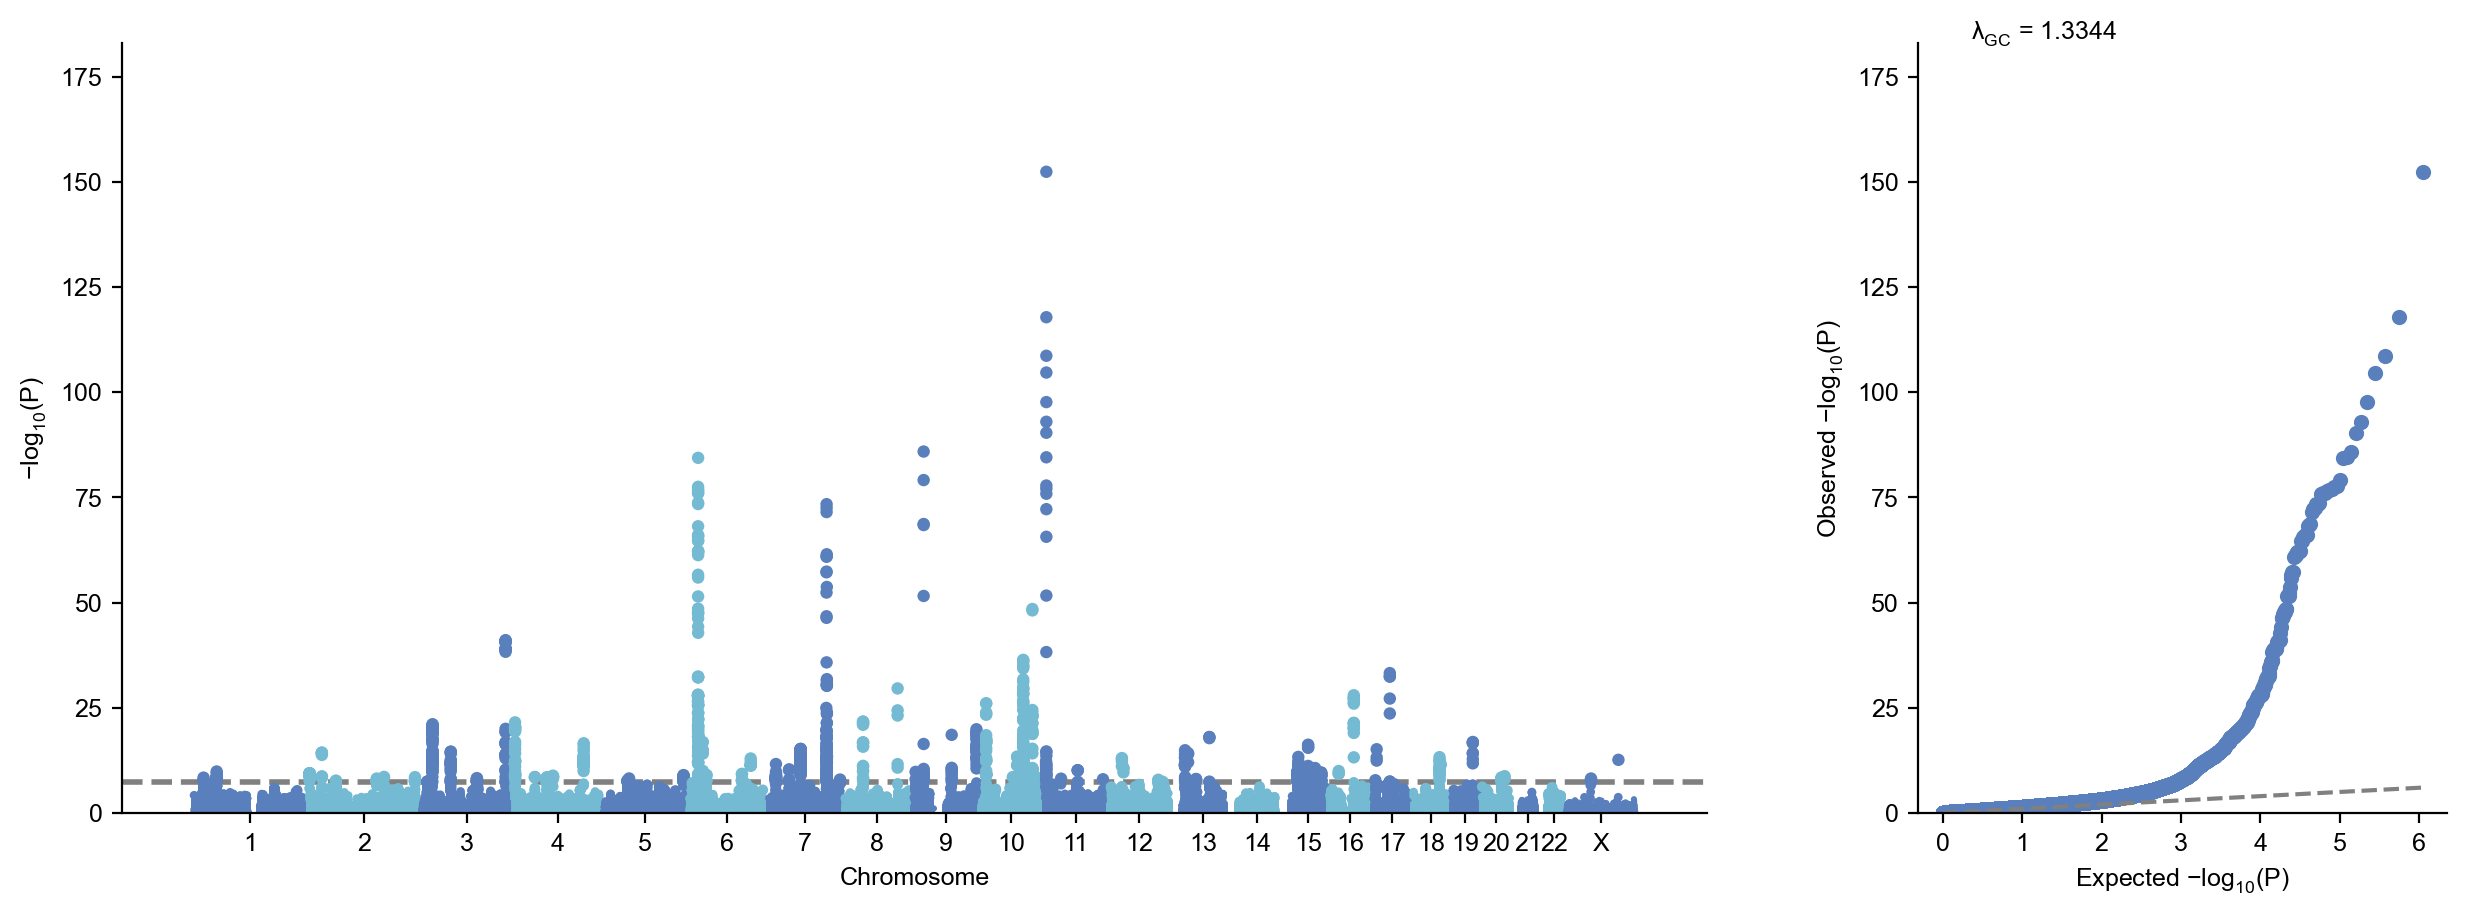

In [7]:
mysumstats.plot_mqq()

Usando `.plot_mqq()`, puedes generar fácilmente los gráficos de Manhattan y QQ, pero en este caso, los gráficos sin manipulación no son muy informativos y generar todos los puntos lleva bastante tiempo. El locus más significativo eclipsó a los demás menos significativos. Para ajustar el gráfico, gwaslab ofrece una amplia gama de opciones de personalización. Por ejemplo, podemos usar `skip` y `cut`:

- skip: omite las variantes con MLOG10P < `skip` para una generación de gráficos más rápida.
- cut: reescala los valores de MLOG10P cuando MLOG10P > `cut`.

2026/03/19 09:18:47 Configured plot style for plot_mqq:mqq
2026/03/19 09:18:47 Starting Manhattan-QQ plot creation (Version v4.1.2)
2026/03/19 09:18:47  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:18:47  - Genomic coordinates version: 19 ...
2026/03/19 09:18:47  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:18:47  - Input sumstats contains 1103020 variants...
2026/03/19 09:18:47  - Manhattan-QQ plot layout mode selected: mqq
2026/03/19 09:18:48 Finished loading specified columns from the statistics
2026/03/19 09:18:48 Start data conversion and sanity check:
2026/03/19 09:18:48  -Sumstats P values are being converted to -log10(P)...
2026/03/19 09:18:48  -Converting data above cut line...
2026/03/19 09:18:48  -Maximum -log10(P) value is 152.39254497678533 .
2026/03/19 09:18:48  -Minus log10(P) values above 20 will be shrunk with a shrinkage factor of 10...
2026/03/19 09:18:48 Finished data conversion and sanity check.
2026/03/19 09:18:48 St

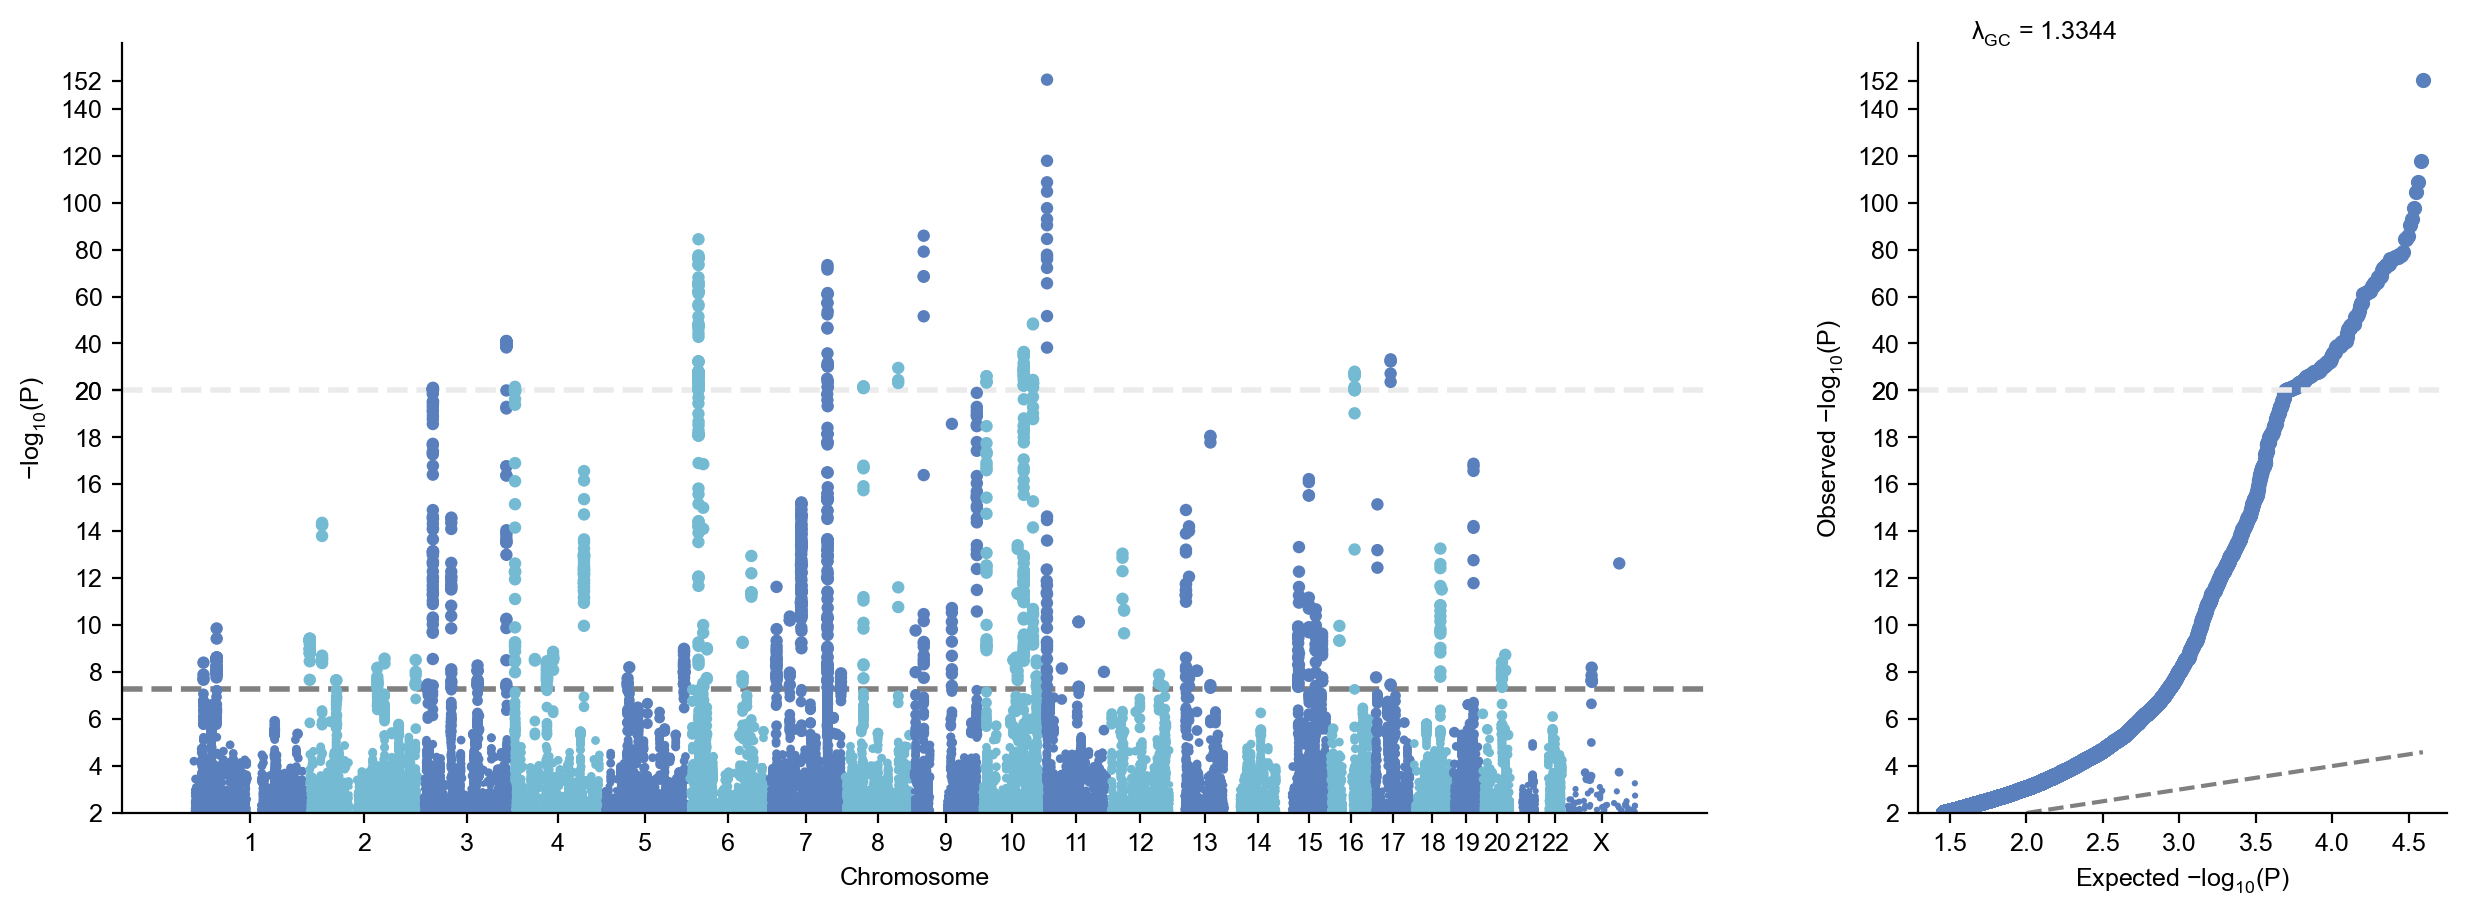

In [8]:
mysumstats.plot_mqq(skip=2, cut=20)

Ahora se ve mejor. Pero ¿qué pasa si queremos anotar algunos de los loci más significativos (por ejemplo, variantes principales con MLOG10P>30) y solo graficar el diagrama de Manhattan?

2026/03/19 09:18:53 Filtered out args for `plot_mqq`: sig_level_lead
2026/03/19 09:18:53 Configured plot style for plot_mqq:m
2026/03/19 09:18:53 Starting Manhattan plot creation (Version v4.1.2)
2026/03/19 09:18:53  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:18:53  - Genomic coordinates version: 19 ...
2026/03/19 09:18:53  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:18:53  - Input sumstats contains 1103020 variants...
2026/03/19 09:18:53  - Manhattan plot layout mode selected: m
2026/03/19 09:18:54 Finished loading specified columns from the statistics
2026/03/19 09:18:54 Start data conversion and sanity check:
2026/03/19 09:18:55  -Sumstats P values are being converted to -log10(P)...
2026/03/19 09:18:55  -Converting data above cut line...
2026/03/19 09:18:55  -Maximum -log10(P) value is 152.39254497678533 .
2026/03/19 09:18:55  -Minus log10(P) values above 20 will be shrunk with a shrinkage factor of 10...
2026/03/19 09:18:55 Finish

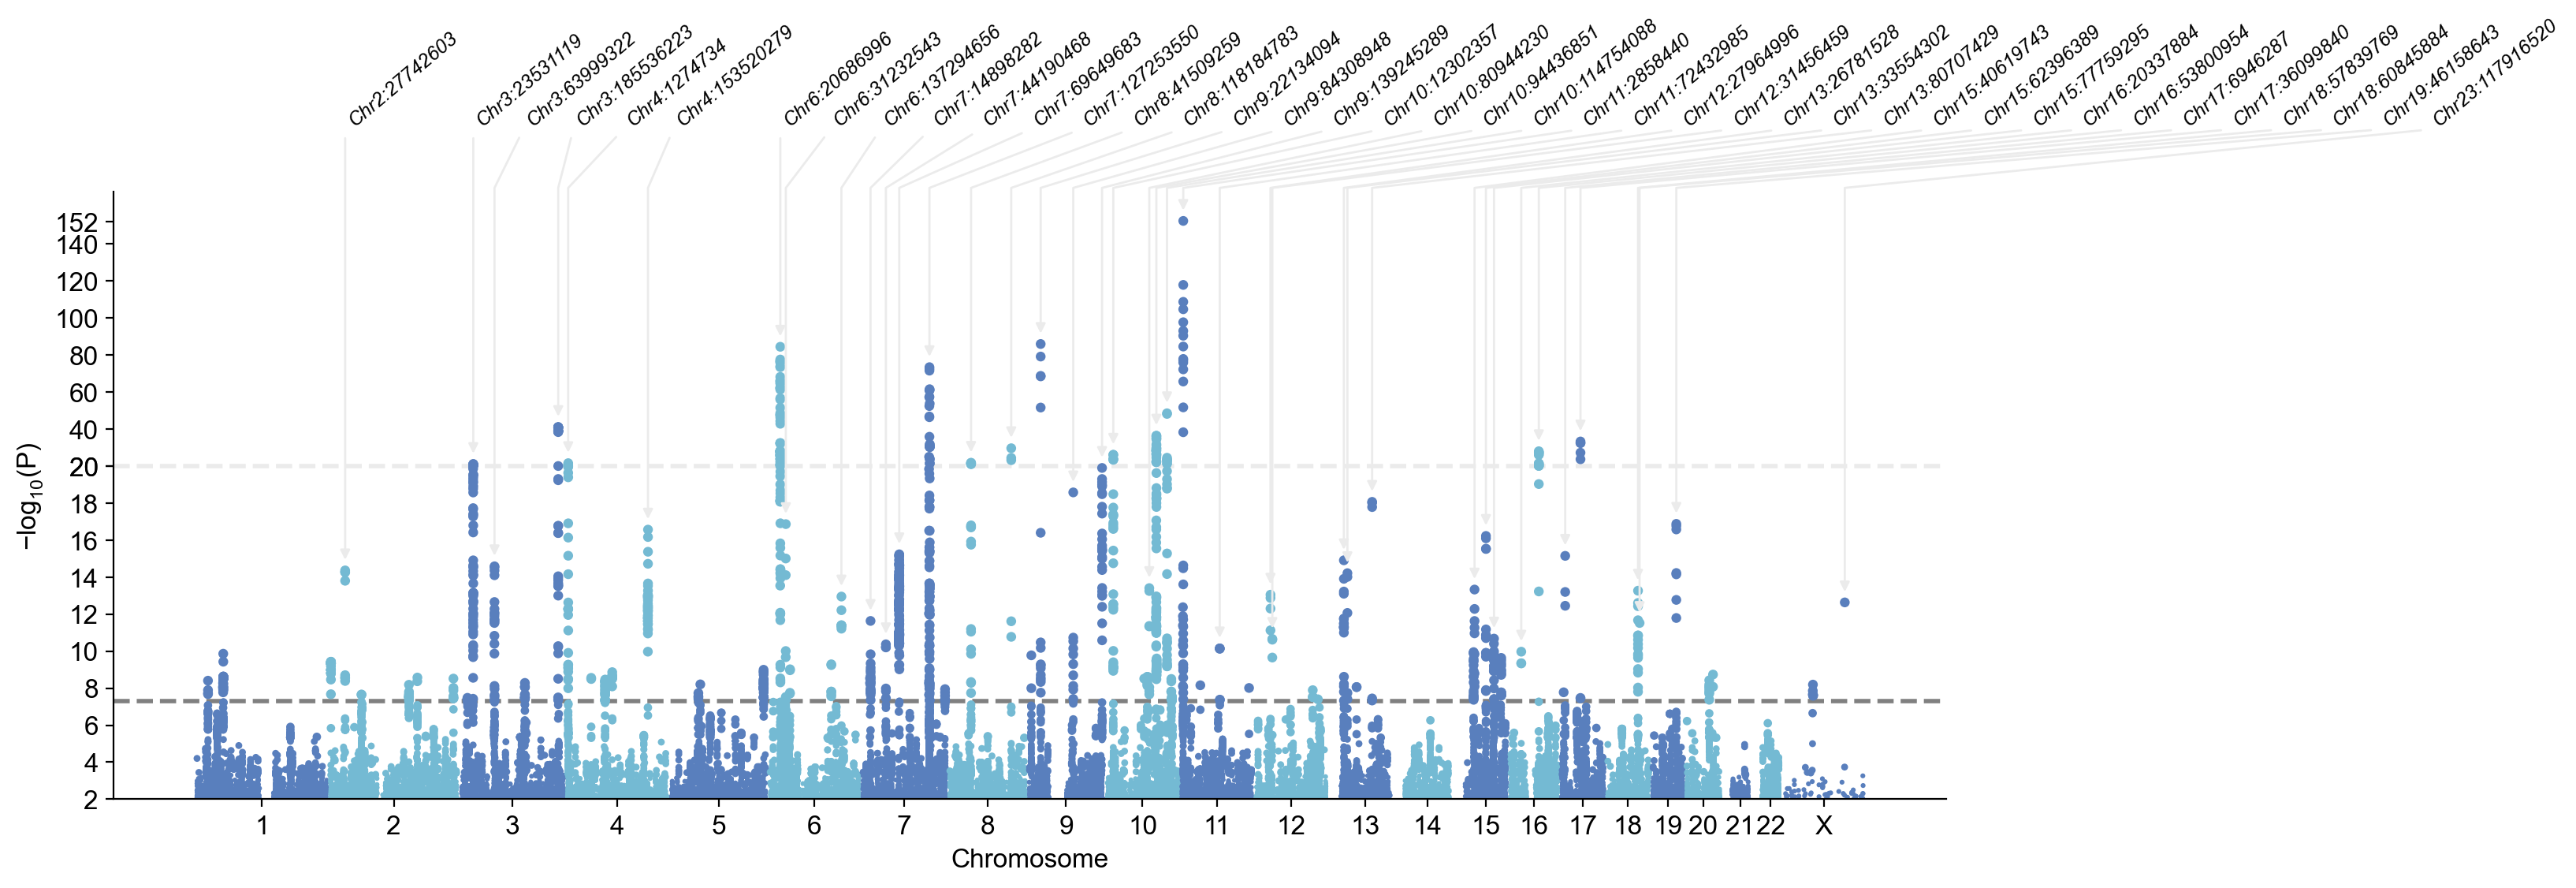

In [9]:
mysumstats.plot_mqq(skip=2, cut=20, mode="m", anno=True, sig_level_lead=1e-30)

gwaslab admite una amplia gama de opciones personalizables. Para obtener más información sobre otras opciones para gráficos de Manhattan y Q-Q, consulte: https://cloufield.github.io/gwaslab/Visualization/

## Estandarización y control de calidad: `.basic_check()`

Antes de cualquier manipulación o análisis, es necesario verificar primero el ID de variante (SNPID), el rsID, el cromosoma (CHR), la posición del par de bases (POS), los alelos (EA y NEA) y las estadísticas. gwaslab proporciona una función integral para esto: `.basic_check()`.

Nota: En ocasiones, es necesario realizar esta verificación antes de graficar si las estadísticas sumadas no están en un formato estándar.

In [10]:
#check SNPID,rsID,CHR,POS,EA, NEA and statistics
mysumstats.basic_check()

2026/03/19 09:19:13 Start to check SNPID/rsID ...(v4.1.2)
2026/03/19 09:19:13  -Checking SNPID data type...
2026/03/19 09:19:13  -Converted datatype for SNPID: object -> string
2026/03/19 09:19:13  -Checking if SNPID contains NA strings :na,NA,Na,Nan,NaN,<NA>,null,NULL,#N/A,#VALUE!,N/A,n/a,missing,...
2026/03/19 09:19:13  -Checking if SNPID is CHR:POS:NEA:EA...(separator: - ,: , _)
2026/03/19 09:19:14  -Time taken: 0.870s
2026/03/19 09:19:14 Finished checking SNPID/rsID.
2026/03/19 09:19:14 Start to fix chromosome notation (CHR) ...(v4.1.2)
2026/03/19 09:19:14  -Checking CHR data type...
2026/03/19 09:19:14  -Variants with standardized chromosome notation: 1103020
2026/03/19 09:19:14  -All CHR are already fixed...
2026/03/19 09:19:14  -Time taken: 0.540s
2026/03/19 09:19:14 Finished fixing chromosome notation (CHR).
2026/03/19 09:19:14 Start to fix basepair positions (POS) ...(v4.1.2)
2026/03/19 09:19:14  -Trying to convert datatype for POS: int64 -> Int64...
2026/03/19 09:19:15  -Posi

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566_G_A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718
1,1:752721_A_G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182_A_G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912_C_T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718
4,1:761147_T_C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911_A_G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088_C_A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836_C_T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036_A_G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764


In [11]:
mysumstats.data

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566_G_A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718
1,1:752721_A_G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182_A_G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912_C_T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718
4,1:761147_T_C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911_A_G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088_C_A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836_C_T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036_A_G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764


Al revisar el registro, podemos ver que las estadísticas totales son correctas. Sin embargo, aún encontramos varias variantes que no estaban normalizadas. gwaslab corrigió la posición y los alelos de las inserciones/deleciones no normalizadas. Además, gwaslab estandarizó la notación del cromosoma X a 23.

In fact, `.basic_check()` is a wrapper of the following basic functions, you can also use these separately.

- mysumstats.fix_ID()
- mysumstats.fix_chr()
- mysumstats.fix_pos()
- mysumstats.fix_allele()
- mysumstats.check_sanity()
- mysumstats.check_data_consistency()
- mysumstats.normalize_allele()
- mysumstats.remove_dup()

## Extraer variantes de leads: get_lead()

Vamos a extraer las variantes principales en cada locus significativo para verificar nuestros datos.

Los loci significativos se detectan mediante una ventana deslizante (tamaño de ventana predeterminado: `windowsizekb=500` kb).

Al especificar `anno=True`, GWASLab también anotará la variante principal con los nombres de los genes más cercanos y su distancia.

**Nota**: Si no especificó la compilación al cargar las estadísticas de resumen o no ejecutó `.infer_build()`, debe establecer explícitamente `build="19" (GRCh37/hg19)` o `build="38" (GRCh38/hg38)` aquí para la anotación.

**Nota**: GWASLab descargará los archivos de referencia la primera vez que lo ejecute. En este caso, `ensembl_hg19_gtf_protein_coding` se descargó y procesó automáticamente.

In [12]:
mysumstats.get_lead(anno=True)

2026/03/19 09:19:25  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:19:25 Start to extract lead variants ...(v4.1.2)
2026/03/19 09:19:25  -Processing 1103020 variants...
2026/03/19 09:19:25  -Significance threshold : 5e-08
2026/03/19 09:19:25  -Sliding window size: 500  kb
2026/03/19 09:19:25  -Using P for extracting lead variants...
2026/03/19 09:19:25  -Found 1271 significant variants in total...
2026/03/19 09:19:25  -Identified 75 lead variants!
2026/03/19 09:19:25  -Annotating variants using references:ensembl
2026/03/19 09:19:25  -Annotating variants using references based on genome build:19
2026/03/19 09:19:25  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:19:25 Start to annotate variants with nearest gene name(s) ...(v4.1.2)
2026/03/19 09:19:25  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:19:25  -Assigning Gene name using ensembl_hg19_gtf for protein coding genes
2026/03/19 09:19:25 File not exist.
2026/03/19 09:19:25 Start to 

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,LOCATION,GENE
8927,1:22046558_A_C,1,22046558,C,A,1960099,0.2527,0.0607,0.0103,3.941000e-09,191764,0,USP48
19220,1:51174330_C_T,1,51174330,C,T,1960099,0.7902,0.0723,0.0113,1.380000e-10,191764,0,FAF1
90573,2:637597_C_T,2,637597,C,T,1960099,0.9017,0.0938,0.0150,3.725000e-10,191764,-29738,TMEM18
102403,2:27742603_T_C,2,27742603,C,T,1960099,0.5613,-0.0690,0.0088,4.358000e-15,191764,0,GCKR
117019,2:58959112_G_A,2,58959112,G,A,1960099,0.1754,0.0654,0.0117,2.237000e-08,191764,490605,FANCL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035288,19:46158643_G_T,19,46158643,G,T,1960099,0.6372,0.0805,0.0094,1.332000e-17,191764,9756,EML2
1059172,20:42989777_G_A,20,42989777,G,A,1960099,0.4503,0.0518,0.0088,3.770000e-09,191764,0,HNF4A
1062583,20:50155386_T_C,20,50155386,C,T,1960099,0.4266,0.0538,0.0090,1.836000e-09,191764,0,NFATC2
1101431,X:57150010_C_T,23,57150010,C,T,1960099,0.3012,0.0443,0.0076,6.427000e-09,191764,2030,SPIN2B


Extrajimos un total de 75 variantes principales con un tamaño de ventana deslizante de 500 kb de este conjunto de datos procesado.

## Utilice el SNPID para crear un gráfico mqq altamente personalizado.

GWASLab puede crear gráficos de Manhattan mucho más complejos.

Por ejemplo: - Anotar las variantes principales con los nombres de genes más cercanos (umbral de anotación p<1e-20)
- Anotar las variantes seleccionadas con textos proporcionados por el usuario
- Identificar algunas variantes
- Resaltar algunos loci
- Gráfico Q-Q estratificado por MAF
- Guardar como my_first_mqq_plot.png con {"dpi":400,"facecolor":"white"}

2026/03/19 09:28:58 Filtered out args for `plot_mqq`: sig_level_lead
2026/03/19 09:28:58 Configured plot style for plot_mqq:mqq
2026/03/19 09:28:58  -QC is finished according to meta. Quick QC will be skipped.
2026/03/19 09:28:58 Starting Manhattan-QQ plot creation (Version v4.1.2)
2026/03/19 09:28:58  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:28:58  - Genomic coordinates version: 19 ...
2026/03/19 09:28:58  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:28:58  - Input sumstats contains 1103020 variants...
2026/03/19 09:28:58  - Manhattan-QQ plot layout mode selected: mqq
2026/03/19 09:28:58  -Highlight locis (#CB132D): 7:127253550_C_T,11:2858440_G_A
2026/03/19 09:28:58   -highlight_windowkb is set to: 1000 kb
2026/03/19 09:28:58  -Pinpoint variants (green): 9:22134094_T_C,6:20686996_C_A
2026/03/19 09:28:58  -EAF data type is already numeric. Skipping conversion...
2026/03/19 09:28:58 Finished loading specified columns from the statistic

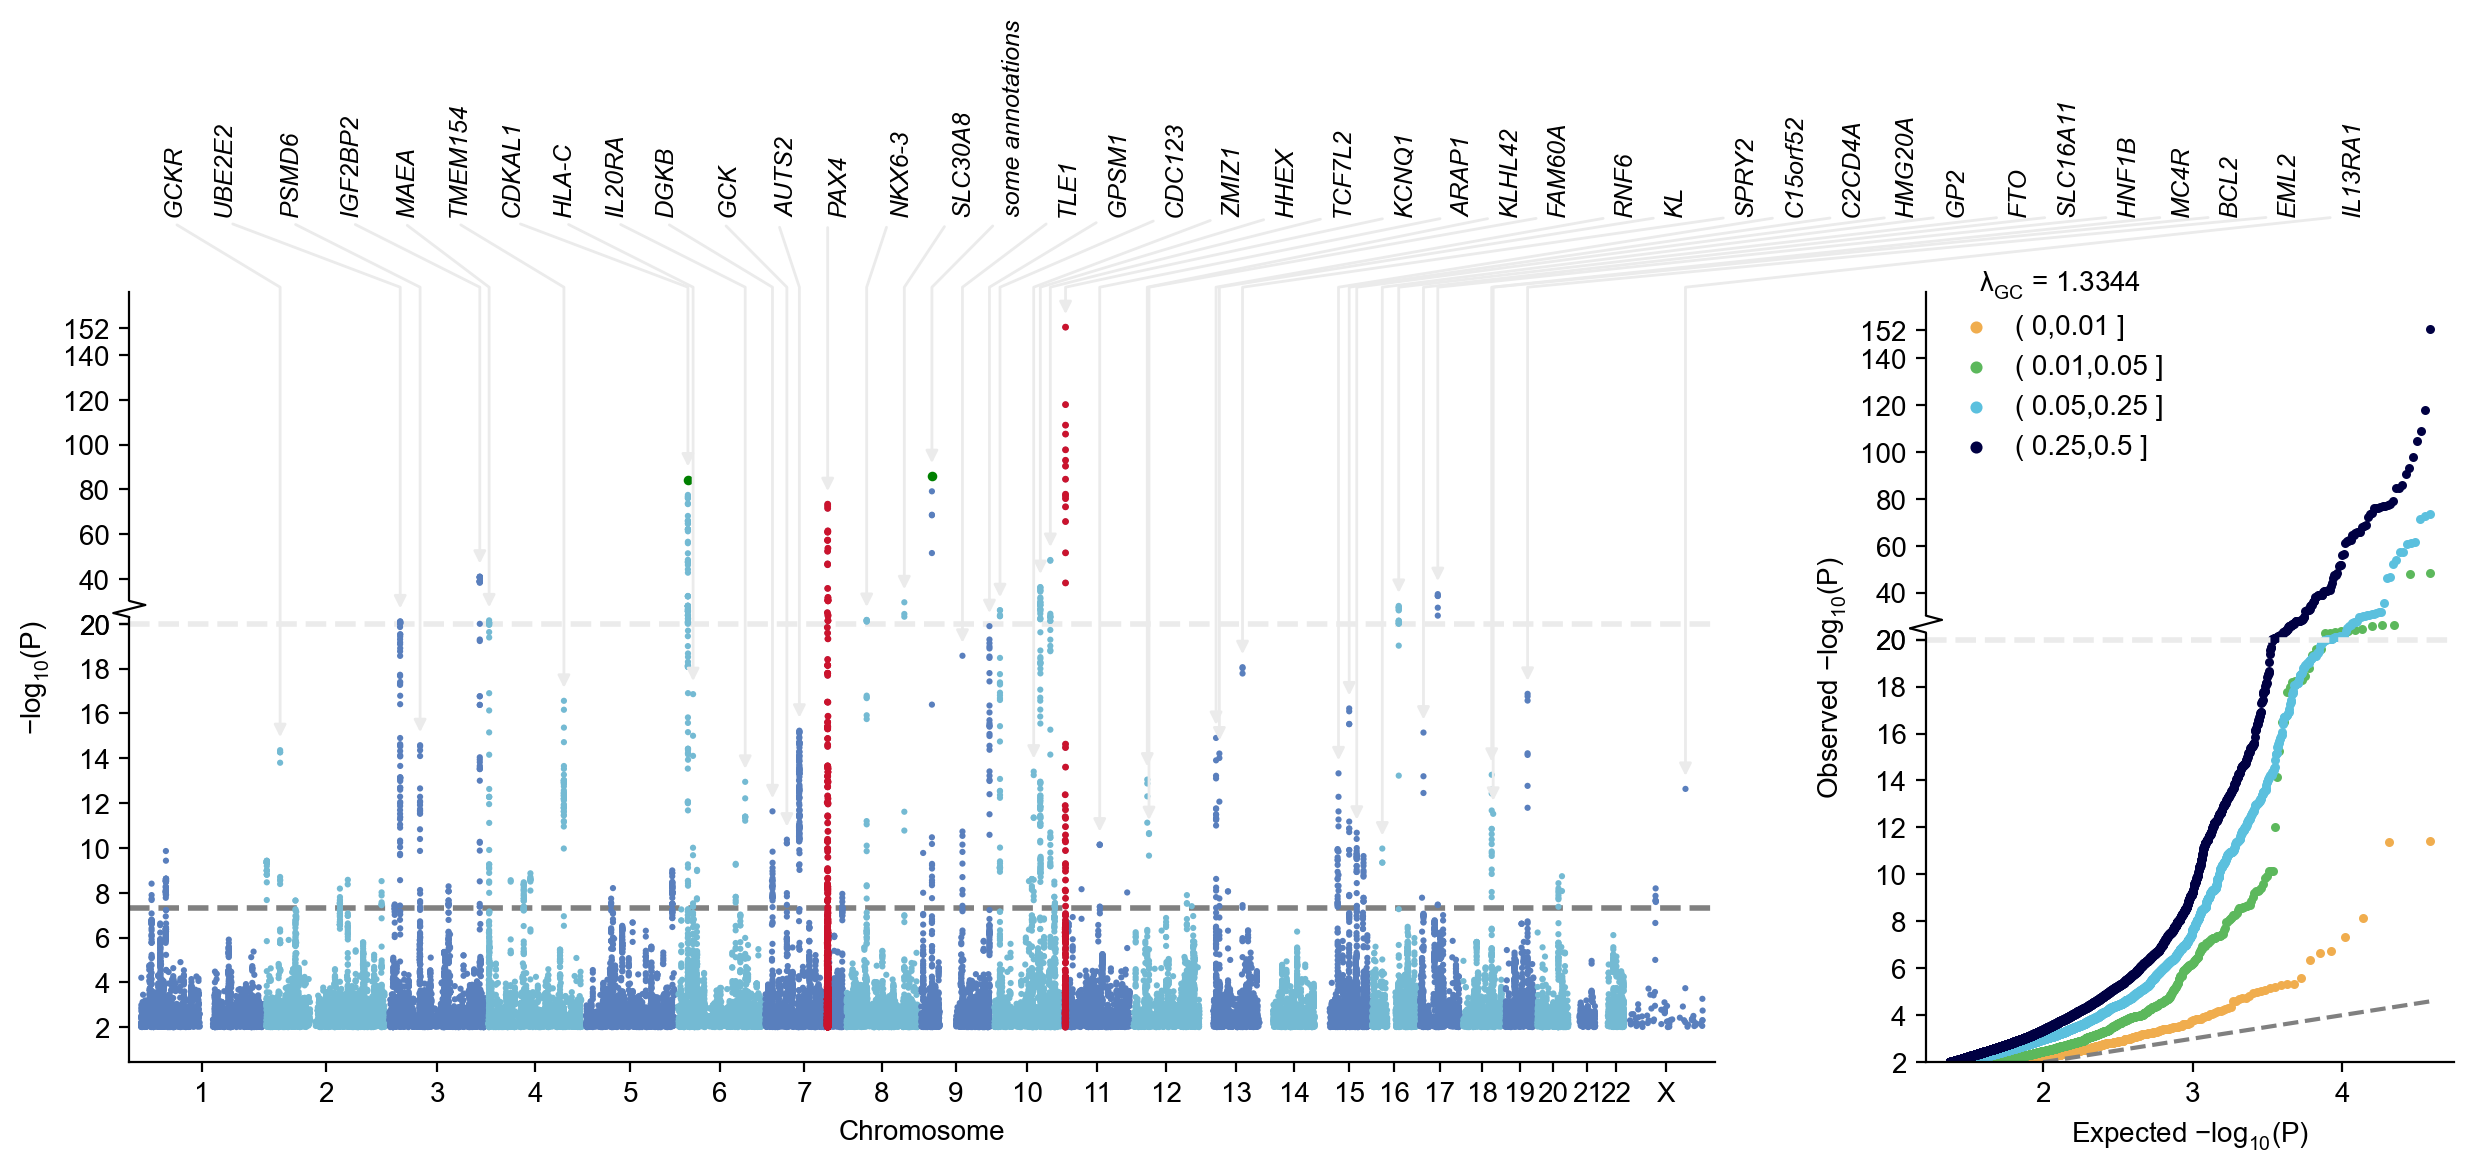

In [15]:
mysumstats.plot_mqq(mode="mqq",
                    cut=20,
                    skip=2,
                    anno="GENENAME",
                    sig_level_lead=1e-20,
                    anno_alias={"9:22134094_T_C": "some annotations"},
                    anno_style="expand",
                    xpad=0.01,
                    pinpoint=["9:22134094_T_C", "6:20686996_C_A"],
                    pinpoint_color="green",
                    highlight=["7:127253550_C_T", "11:2858440_G_A"],
                    highlight_windowkb=1000,
                    stratified=True,
                    jagged=True,
                    marker_size=(5, 5),
                    fig_kwargs={"figsize": (15, 5), "dpi": 300},  # cambio aquí
                    save="my_first_mqq_plot.png",
                    save_kwargs={"dpi": 400, "facecolor": "white"})

## Gráfico regional rápido sin información de LD

gwaslab también puede generar gráficos regionales con o sin archivos de referencia LD.

Primero creamos un gráfico regional sin referencias especificando `modo` y `región`.

2026/03/19 09:29:24 Filtered out args for `plot_mqq`: highlight
2026/03/19 09:29:24 Configured plot style for plot_mqq:r
2026/03/19 09:29:24  -QC is finished according to meta. Quick QC will be skipped.
2026/03/19 09:29:24 Starting Region plot creation (Version v4.1.2)
2026/03/19 09:29:24  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:29:24  - Genomic coordinates version: 19 ...
2026/03/19 09:29:24  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:29:24  - Input sumstats contains 1103020 variants...
2026/03/19 09:29:24  - Region plot layout mode selected: r
2026/03/19 09:29:24  -Region to plot : chr7:126253550-128253550.
2026/03/19 09:29:24  -Normalized region: (CHR=7, START=126253550, END=128253550)
2026/03/19 09:29:24 Start to filter variants within a specific genomic region ...(v4.1.2)
2026/03/19 09:29:24  -Current Dataframe shape : 1103020 x 7 ; Memory usage: 48.41 MB
2026/03/19 09:29:24  -Normalized region: (CHR=7, START=126253550, END=12

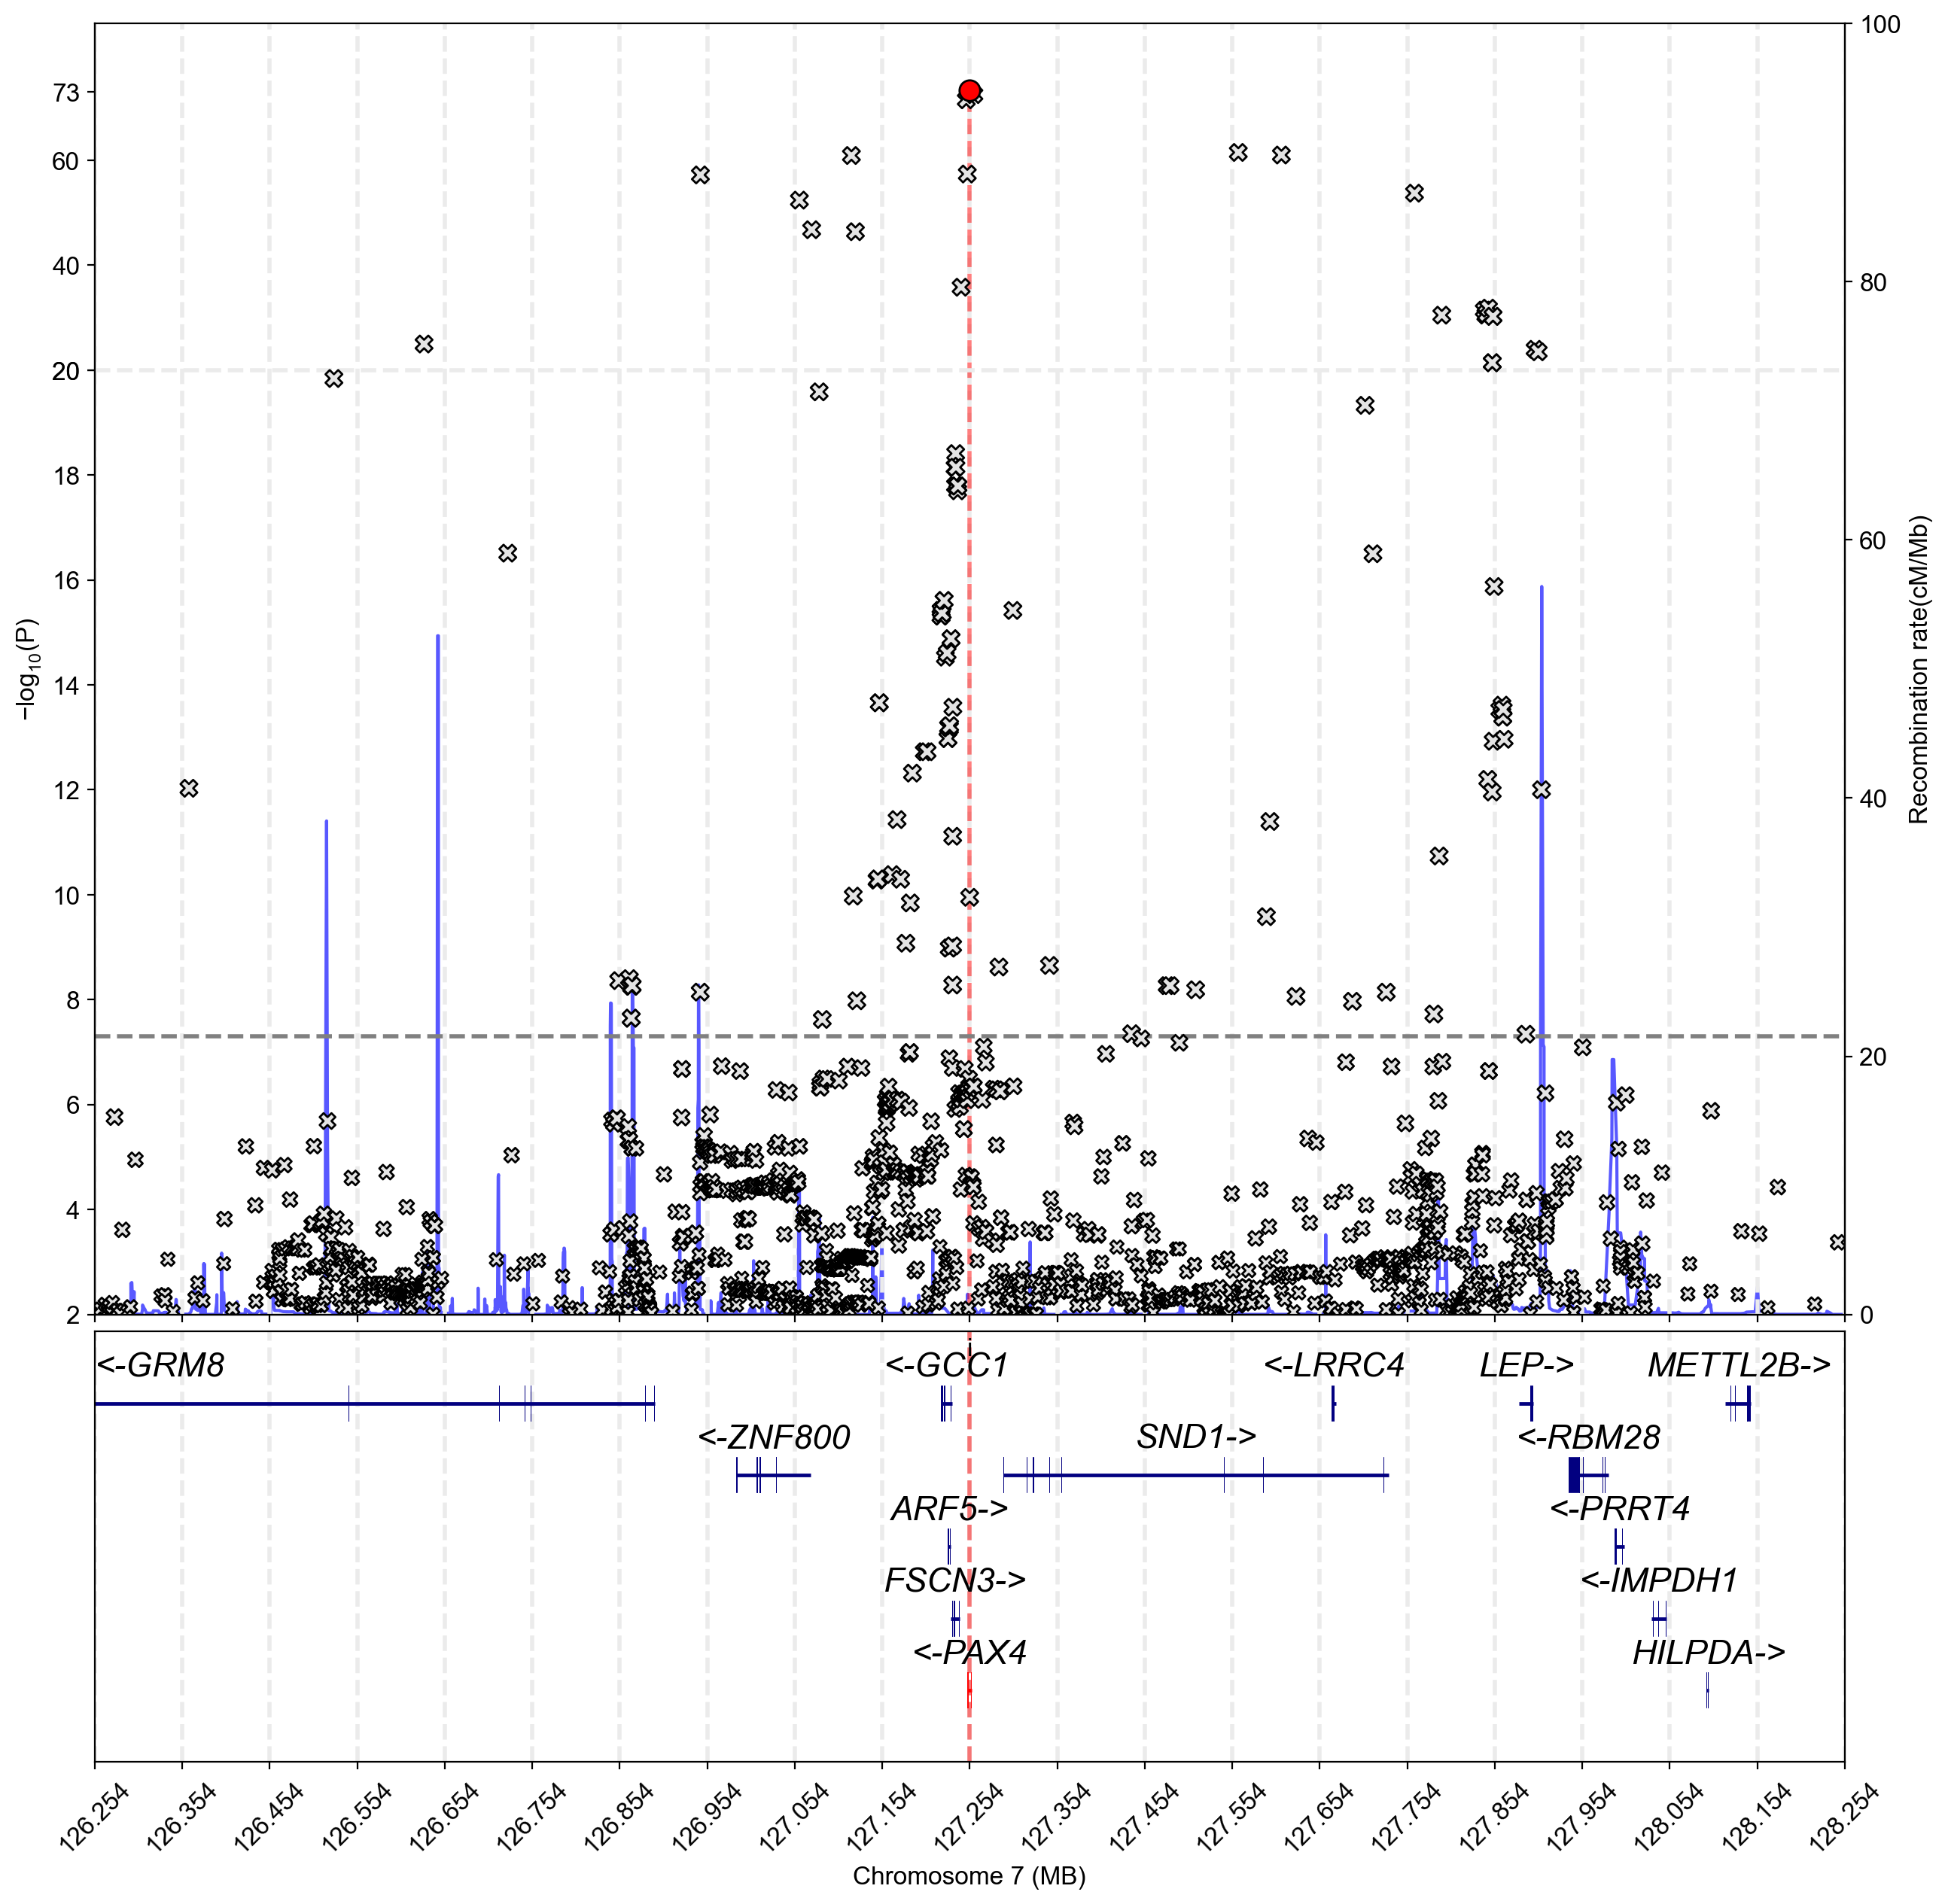

In [16]:
mysumstats.plot_mqq(mode="r",skip=2,cut=20, region=(7,126253550,128253550),region_grid=True)

## Descarga del archivo de referencia

Para generar un gráfico regional completo, se requieren archivos `vcf` proporcionados por el usuario o archivos `vcf` preprocesados ​​por GWASLab (por ejemplo, el proyecto 1000 Genomas; consulte la referencia: https://cloufield.github.io/gwaslab/Reference/).

GWASLab ofrece conjuntos de datos preprocesados ​​de 1000 Genomas para su descarga.

### Consultar referencias disponibles en gwaslab

Actualice primero la lista de referencias disponibles si es necesario.

In [17]:
# gl.update_available_ref()

In [17]:
gl.check_available_ref()

2026/03/19 09:30:00 Start to check available reference files...
2026/03/19 09:30:00  - Available keywords:  1kg_eas_hg19 1kg_eur_hg19 1kg_eas_hg38 1kg_eur_hg38 1kg_sas_hg19 1kg_amr_hg19 1kg_sas_hg38 1kg_amr_hg38 1kg_afr_hg19 1kg_pan_hg19 1kg_afr_hg38 1kg_pan_hg38 dbsnp_v151_hg19 dbsnp_v151_hg38 dbsnp_v157_hg19 dbsnp_v157_hg38 ucsc_genome_hg19 ucsc_genome_hg38 1kg_dbsnp151_hg19_auto 1kg_dbsnp151_hg38_auto recombination_hg19 recombination_hg38 ensembl_hg19_gtf ensembl_hg38_gtf refseq_hg19_gtf refseq_hg38_gtf testlink 19to38 38to19 1kg_hm3_hg38_eaf 1kg_hm3_hg19_eaf


{'1kg_eas_hg19': {'description': '1000 Genomes Project East Asian (1KG EAS) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EAS population.',
  'suggested_use': 'LD reference panel for creating region plot; infer strand for EAS population'},
 '1kg_eur_hg19': {'description': '1000 Genomes Project European (1KG EUR) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EUR population.',
  'suggested_use': 'LD reference panel for creating region plot; infer strand for EUR population'},
 '1kg_eas_hg38': {'description': '1000 Genomes Project East Asian (1KG EAS) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EAS population.',
 

Puedes ver los archivos de referencia disponibles actualmente (de la fuente original o preprocesados ​​por gwaslab).

### Descargar referencia usando gwaslab

Seleccione la palabra clave y use `download_ref` para descargar los archivos. Los archivos descargados se guardarán por defecto en `~/.gwasalb`.

- `1kg_eas_hg19`: conjunto de datos de muestras EAS procesadas del Proyecto 1000 Genomas (hg19; ~2,8 GB). La descarga puede tardar varios minutos.

In [35]:
# ~2.8GB
gl.download_ref("1kg_eas_hg19")

2026/03/19 09:57:24 Start to download  1kg_eas_hg19  ...
2026/03/19 09:57:24  -Downloading to: /Users/alex/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2026/03/19 10:05:19  - Updating record in config file...
2026/03/19 10:05:19  -Downloading to: /Users/alex/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2026/03/19 10:05:22  - Updating record in config file...
2026/03/19 10:05:22 Downloaded  1kg_eas_hg19  successfully!


In [36]:
gl.check_downloaded_ref()

2026/03/19 10:08:16 Start to check downloaded reference files...
2026/03/19 10:08:16  -Checking the config file:/Users/alex/miniconda3/envs/gwaslab/lib/python3.12/site-packages/gwaslab/data/config.json
2026/03/19 10:08:16  -Config file exists.
2026/03/19 10:08:16  -Updating config.json...
2026/03/19 10:08:16  - Local file keywords:  1kg_eas_hg19 ensembl_hg19_gtf recombination_hg19


{'1kg_eas_hg19': {'local_path': '/Users/alex/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz',
  'description': '1000 Genomes Project East Asian (1KG EAS) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EAS population.',
  'suggested_use': 'LD reference panel for creating region plot; infer strand for EAS population'},
 'ensembl_hg19_gtf': {'local_path': '/Users/alex/.gwaslab/Homo_sapiens.GRCh37.87.chr.gtf.gz',
  'description': 'Ensembl annotation for hg19 (GRCh37) release 87, providing comprehensive gene models, transcript structures, and functional annotations for the human genome.',
  'suggested_use': 'Gene annotation and functional analysis'},
 'recombination_hg19': {'local_path': '/Users/alex/.gwaslab/recombination/hg19/recombination_hg19.tar.gz',
  'description': 'Recombination map for hg19 (GRCh37), providing genetic distance estimates in centimorgans u

Tras la descarga, utilice `get_path` para obtener la ruta del archivo especificando la palabra clave.

In [37]:
gl.get_path("1kg_eas_hg19")

'/Users/alex/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz'

**Nota**:
- Si `tabix` está disponible en la variable de entorno PATH, la velocidad mejorará considerablemente. De lo contrario, los archivos VCF se cargarán desde el principio.

- tabix: http://www.htslib.org/download/

### Gráficos de región con o sin archivos de referencia LD.

Para crear un gráfico de región con información de desequilibrio de ligamiento (LD), debe pasar la ruta del archivo VCF de referencia a `vcf_path`.

- Para este tutorial, utilizaremos el archivo `1kg_eas_hg19.chr7_126253550_128253550.vcf.gz` incluido en el conjunto de datos de ejemplo.

- También puede usar el archivo preprocesado descargado, como `vcf_path = gl.get_path("1kg_eas_hg19")`, o sus propios archivos VCF.

2026/03/19 09:31:07 Filtered out args for `plot_mqq`: highlight
2026/03/19 09:31:07 Configured plot style for plot_mqq:r
2026/03/19 09:31:07  -QC is finished according to meta. Quick QC will be skipped.
2026/03/19 09:31:07 Starting Region plot creation (Version v4.1.2)
2026/03/19 09:31:07  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 09:31:07  - Genomic coordinates version: 19 ...
2026/03/19 09:31:07  - Genome-wide significance level to plot is set to 5e-08 ...
2026/03/19 09:31:07  - Input sumstats contains 1103020 variants...
2026/03/19 09:31:07  - Region plot layout mode selected: r
2026/03/19 09:31:07  -Region to plot : chr7:126253550-128253550.
2026/03/19 09:31:07  -Normalized region: (CHR=7, START=126253550, END=128253550)
2026/03/19 09:31:07 Start to filter variants within a specific genomic region ...(v4.1.2)
2026/03/19 09:31:07  -Current Dataframe shape : 1103020 x 7 ; Memory usage: 48.41 MB
2026/03/19 09:31:07  -Normalized region: (CHR=7, START=126253550, END=12

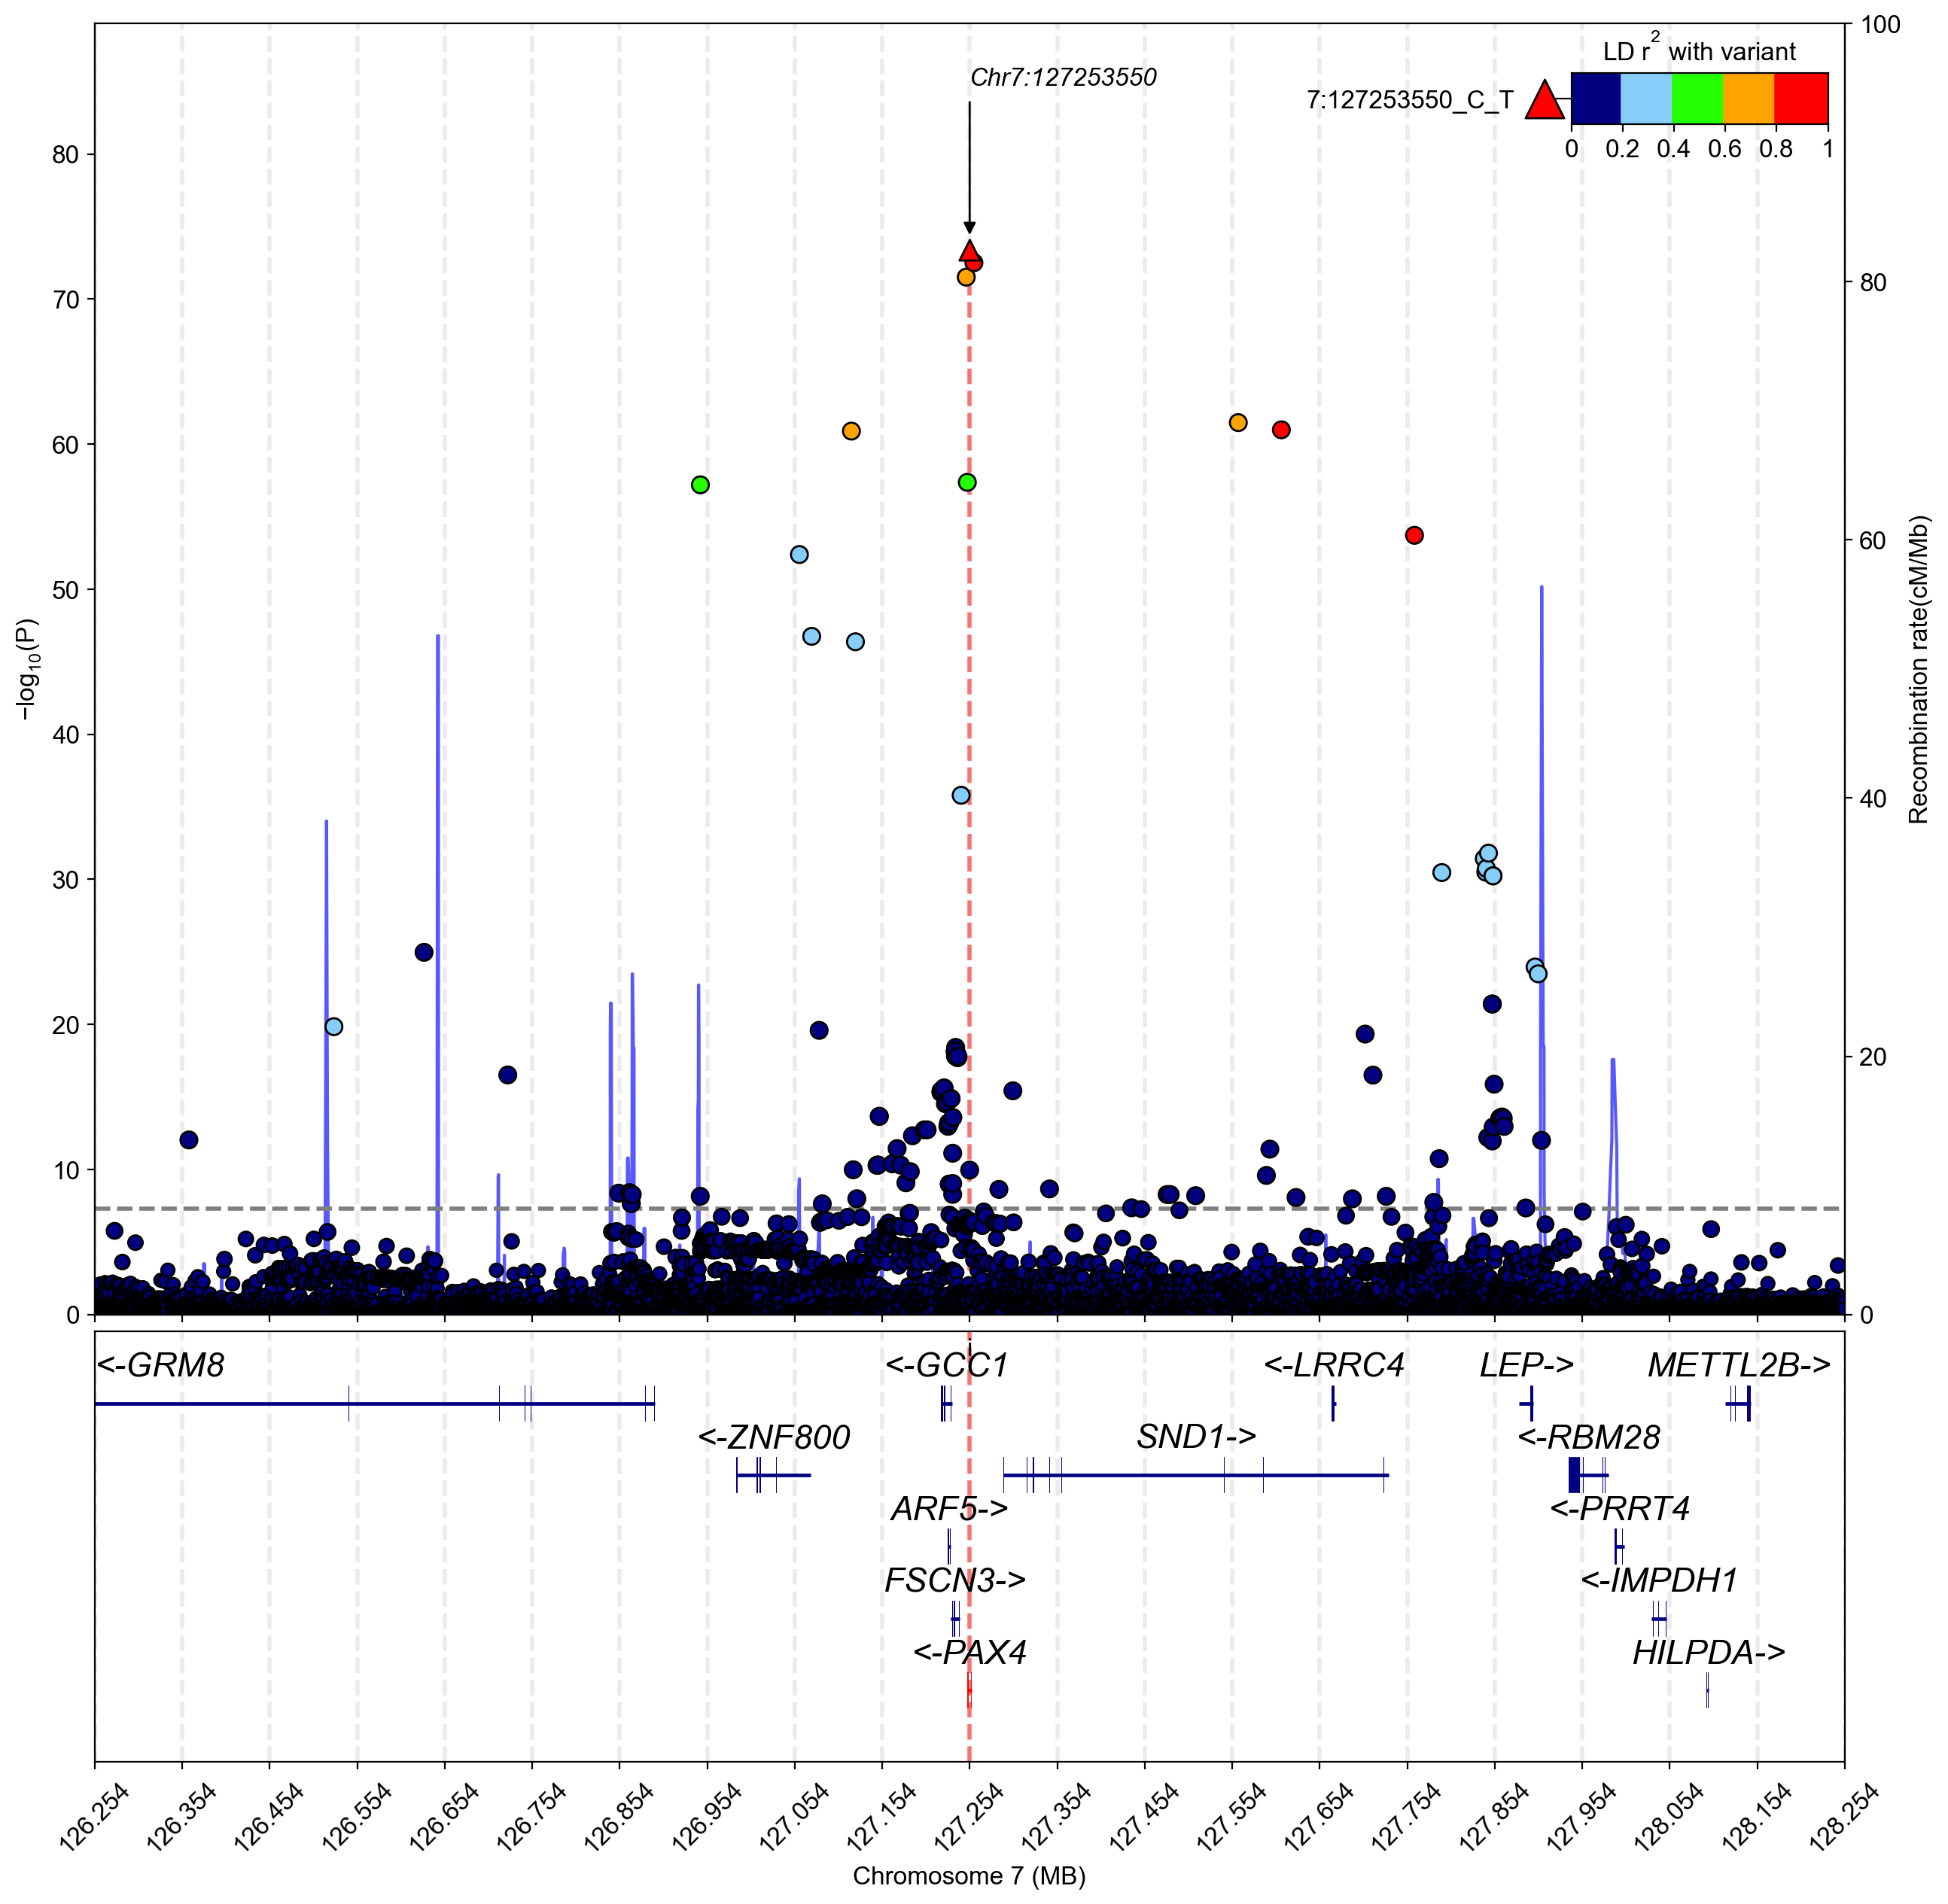

In [19]:
mysumstats.plot_mqq(mode="r",
                    region=(7, 126253550, 128253550),
                    region_grid=True,
                    anno=True,
                    anno_kwargs={"rotation": 0, "fontsize": 12},  # <--- cambio aquí
                    vcf_path="sample_data/1kg_eas_hg19.chr7_126253550_128253550.vcf.gz")

**Nota**:
- La versión predeterminada del genoma en GWASLab es `build="19"` (GRCh37/hg19). Puede cambiarla a `build="38"` (GRCh38/hg38) si es necesario.

- Para las pistas de genes, la ruta predeterminada es `gtf_path="ensembl"`. También puede usar `gtf_path="refseq"` (NCBA RefSeq).

## Corregir SNPID

Es posible que observe que el SNPID está en formato `CHR:POS_REF_ALT`. Queremos que el SNPID esté en un formato estandarizado `CHR:POS:REF:ALT`, podemos usar fix_id para esto:

In [20]:
#fixsep : fix ID separator
mysumstats.fix_id(fixsep=True)

2026/03/19 09:31:15 Start to check SNPID/rsID ...(v4.1.2)
2026/03/19 09:31:15  -Checking SNPID data type...
2026/03/19 09:31:15  -Checking if SNPID contains NA strings :na,NA,Na,Nan,NaN,<NA>,null,NULL,#N/A,#VALUE!,N/A,n/a,missing,...
2026/03/19 09:31:15  -Checking if SNPID is CHR:POS:NEA:EA...(separator: - ,: , _)
2026/03/19 09:31:16  -Replacing separators in SNPID with ":" ...
2026/03/19 09:31:18  -Time taken: 3.300s
2026/03/19 09:31:18 Finished checking SNPID/rsID.


,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566:G:A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718
1,1:752721:A:G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182:A:G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912:C:T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718
4,1:761147:T:C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088:C:A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836:C:T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036:A:G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764


In [21]:
mysumstats.data

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566:G:A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718
1,1:752721:A:G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182:A:G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912:C:T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718
4,1:761147:T:C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088:C:A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836:C:T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036:A:G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764


## Anotar rsID

El rsID se asigna mediante dos tipos de archivos de referencia:
- ref_rsid_tsv: archivo tsv para la anotación de variantes de uso común
- ref_rsid_vcf: archivo vcf para la anotación de otras variantes

GWASLab proporciona archivos tsv preprocesados ​​para las variantes de 1KG (~80 MB). Podemos descargar el archivo usando `.download_ref` con palabras clave. En esta ocasión, usaremos `1kg_dbsnp151_hg19_auto`, que es la tabla de conversión SNPID-rsID para las variantes autosómicas del proyecto 1KG (hg19). La descarga tardará unos minutos.

In [38]:
# 961M
gl.download_ref("1kg_dbsnp151_hg19_auto")

2026/03/19 10:08:58 Start to download  1kg_dbsnp151_hg19_auto  ...
2026/03/19 10:08:58  -Downloading to: /Users/alex/.gwaslab/1kg_dbsnp151_hg19_auto.txt.gz
2026/03/19 10:12:18  - Updating record in config file...
2026/03/19 10:12:18 Downloaded  1kg_dbsnp151_hg19_auto  successfully!


Por ahora, solo usamos el archivo "1kg_dbsnp151_hg19_auto_hm3_chr7_variants.txt.gz" incluido en el conjunto de datos de muestra.

In [22]:
mysumstats.assign_rsid(ref_rsid_tsv= "sample_data/1kg_dbsnp151_hg19_auto_hm3_chr7_variants.txt.gz")

2026/03/19 09:31:28 Start to assign rsID using reference file ...(v4.1.2)
2026/03/19 09:31:28  -Number of threads/cores to use: 1
2026/03/19 09:31:28  -1103020 rsID could be possibly fixed...
2026/03/19 09:31:28  -Setting block size:  5000000
2026/03/19 09:31:28  -Loading block: 0   
2026/03/19 09:31:32  -rsID annotation for 2564 variants needed to be fixed!
2026/03/19 09:31:32  -Annotated 1100456 rsID successfully!
2026/03/19 09:31:32  -Current Dataframe shape : 1103020 x 12 ; Memory usage: 88.38 MB
2026/03/19 09:31:32  -Time taken: 4.322s
2026/03/19 09:31:32 Finished assign rsID using reference file.


,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,rsID
0,1:752566:G:A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718,rs3094315
1,1:752721:A:G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718,rs3131972
2,1:754182:A:G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718,rs3131969
3,1:760912:C:T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718,rs1048488
4,1:761147:T:C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718,rs3115850
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764,<NA>
1103016,X:154379088:C:A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764,<NA>
1103017,X:154536836:C:T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764,<NA>
1103018,X:154763036:A:G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764,<NA>


In [23]:
mysumstats.data

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,rsID
0,1:752566:G:A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718,rs3094315
1,1:752721:A:G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718,rs3131972
2,1:754182:A:G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718,rs3131969
3,1:760912:C:T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718,rs1048488
4,1:761147:T:C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718,rs3115850
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764,<NA>
1103016,X:154379088:C:A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764,<NA>
1103017,X:154536836:C:T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764,<NA>
1103018,X:154763036:A:G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764,<NA>


- Anotamos 1.100.456 variantes (1.100.456 / 1.103.020 = 99,7%) utilizando la tabla de conversión.

- Para la anotación de otras variantes (0,3%), podríamos necesitar el archivo vcf de referencia de dbSNP.

### Maximizar la anotación

Para la anotación de variantes poco comunes, podemos usar archivos VCF descargados de la base de datos dbSNP del NCBI (https://ftp.ncbi.nih.gov/snp/latest_release/VCF/).

Nota: - El tamaño del archivo es enorme (>20 GB) y la descarga puede tardar varias horas. (Este paso se puede omitir en este tutorial).
- Especifique `chr_dict` para que coincida con las notaciones de cromosomas en sumstats y en los archivos VCF.

Parámetros:
- `ref_rsid_vcf`: ruta al archivo vcf de rsID de referencia
- `n_cores`: número de subprocesos a utilizar

Para este tutorial, utilizamos el archivo `b157_2564.vcf.gz` en el conjunto de datos de ejemplo, que se extrae de la versión b157 del archivo VCF de dbSNP.

In [27]:
mysumstats.assign_rsid(ref_rsid_vcf="sample_data/b157_2564.vcf.gz")


2026/03/19 09:33:52 Start to assign rsID using reference file ...(v4.1.2)
2026/03/19 09:33:52  -Number of threads/cores to use: 1
2026/03/19 09:33:52  -Assigning rsID based on CHR:POS and REF:ALT/ALT:REF...
2026/03/19 09:33:59  -rsID annotation for 98 variants need to be fixed!
2026/03/19 09:33:59  -Annotated 2466 rsID successfully!
2026/03/19 09:33:59  -Time taken: 7.057s
2026/03/19 09:33:59 Finished assign rsID using reference file.


,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,rsID
0,1:752566:G:A,1,752566,G,A,1960099,0.8422,-0.0155,0.0131,0.2350,166718,rs3094315
1,1:752721:A:G,1,752721,G,A,1960099,0.2507,0.0204,0.0147,0.1650,166718,rs3131972
2,1:754182:A:G,1,754182,G,A,1960099,0.2505,0.0222,0.0166,0.1817,166718,rs3131969
3,1:760912:C:T,1,760912,C,T,1960099,0.8425,-0.0171,0.0148,0.2480,166718,rs1048488
4,1:761147:T:C,1,761147,C,T,1960099,0.1581,0.0171,0.0148,0.2480,166718,rs3115850
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,23,154343911,G,A,1960099,0.8058,0.0019,0.0090,0.8297,191764,rs4898358
1103016,X:154379088:C:A,23,154379088,C,A,1960099,0.7783,0.0027,0.0094,0.7723,191764,rs5987090
1103017,X:154536836:C:T,23,154536836,C,T,1960099,0.2196,-0.0084,0.0085,0.3192,191764,rs12013168
1103018,X:154763036:A:G,23,154763036,G,A,1960099,0.3686,-0.0102,0.0105,0.3302,191764,rs5940466


Después de esto, solo 98 variantes no estaban anotadas, en su mayoría inserciones/deleciones que no están disponibles en el archivo VCF de referencia.

In [28]:
mysumstats.data.loc[mysumstats.data["rsID"].isna(),:]

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,rsID
514556,7:126557427:CCACACACACA:C,7,126557427,C,CCACACACACA,1960399,0.9952,-0.0497,0.0724,0.49210,191764,<NA>
518422,7:127424966:C:CTTGTTTTGTTTTGTTTTGTTTTG,7,127424966,C,CTTGTTTTGTTTTGTTTTGTTTTG,1960399,0.0034,-0.1844,0.1342,0.16940,191764,<NA>
519593,7:127765815:A:AAAATAAATAAATAAATAAAT,7,127765815,AAAATAAATAAATAAATAAAT,A,1960399,0.9442,-0.0262,0.0239,0.27350,191764,<NA>
519882,7:127825806:T:TACACAC,7,127825806,TACACAC,T,1960399,0.9640,0.0721,0.0283,0.01093,191764,<NA>
519883,7:127825806:T:TACAC,7,127825806,TACAC,T,1960399,0.8700,0.0232,0.0143,0.10540,191764,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
1102883,X:145493373:TAA:T,23,145493373,TAA,T,1960399,0.1006,0.0098,0.0120,0.41410,191764,<NA>
1102893,X:145943926:TA:T,23,145943926,TA,T,1960399,0.5974,-0.0076,0.0118,0.52130,191764,<NA>
1102959,X:151172462:CGT:C,23,151172462,C,CGT,1960399,0.7959,0.0066,0.0138,0.63190,191764,<NA>
1102972,X:152032452:A:AT,23,152032452,AT,A,1960399,0.9633,0.0111,0.0239,0.64110,191764,<NA>


## Armonización

gwaslab puede armonizar las estadísticas sumatorias basándose en archivos de referencia.

- ref_seq: archivo fasta del genoma de referencia para el alineamiento de alelos.
- ref_infer: archivo vcf con información de frecuencia alélica para inferir la hebra y comparar la frecuencia alélica.
- ref_alt_freq: campo en la sección INFO del archivo vcf para la frecuencia alélica alternativa.

Podemos utilizar el genoma de referencia del proyecto 1000 Genomas.

http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/human_g1k_v37.fasta.gz
http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/human_g1k_v37.fasta.fai

Al llamar a `.harmonize()`, primero se llamará a `.basic_check()` para asegurar que el conjunto de datos esté listo para la armonización. Como ya hemos realizado basic_check, establecemos `basic_check=False` aquí. Para `ref_infer`, pasamos los archivos vcf descargados para 1KG EAS y especificamos el campo para la frecuencia del alelo alternativo a AF mediante `ref_alt_freq= "AF"`.

In [41]:
# esto dentro de la  carpeta 1_main_tutorial
# curl -O http://hgdownload.soe.ucsc.edu/goldenPath/hg19/bigZips/hg19.fa.gz
# gunzip hg19.fa.gz

mysumstats.harmonize(basic_check=False,
                     ref_seq="/Volumes/alex/BS_scripts_clase/GWAS-DATA/gwaslab/examples/1_main_tutorial/hg19.fa",
                     ref_infer=gl.get_path("1kg_eas_hg19"),
                     ref_alt_freq="AF")

2026/03/19 10:14:48 Start to check if NEA is aligned with reference sequence ...(v4.1.2)
2026/03/19 10:14:48  -Reference genome FASTA file: /Volumes/alex/BS_scripts_clase/GWAS-DATA/gwaslab/examples/1_main_tutorial/hg19.fa
2026/03/19 10:14:49    -Loading and building numpy fasta records:chr1  chr2  chr3  chr4  chr5  chr6  chr7  chr8  chr9  chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr20  chr19  chr22  chr21  
2026/03/19 10:18:16  -Checking records
2026/03/19 10:18:28    -Checking records for ( len(NEA) <= 4 and len(EA) <= 4 )
2026/03/19 10:18:43    -Checking records for ( len(NEA) > 4 or len(EA) > 4 )
2026/03/19 10:18:45  -Finished checking records
2026/03/19 10:18:45  -Variants allele on given reference sequence :  529805
2026/03/19 10:18:45  -Variants flipped :  570019
2026/03/19 10:18:45   -Raw Matching rate :  99.71%
2026/03/19 10:18:45  -Variants inferred reverse_complement :  0
2026/03/19 10:18:45  -Variants inferred reverse_complement_flipped :  0
2026/03/19 

,SNPID,rsID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566:G:A,rs3094315,1,752566,A,G,1960010,0.1578,0.0155,0.0131,0.2350,166718
1,1:752721:A:G,rs3131972,1,752721,G,A,1960000,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182:A:G,rs3131969,1,754182,G,A,1960000,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912:C:T,rs1048488,1,760912,T,C,1960010,0.1575,0.0171,0.0148,0.2480,166718
4,1:761147:T:C,rs3115850,1,761147,C,T,1960000,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,rs4898358,23,154343911,G,A,1960090,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088:C:A,rs5987090,23,154379088,C,A,1960090,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836:C:T,rs12013168,23,154536836,C,T,1960090,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036:A:G,rs5940466,23,154763036,G,A,1960090,0.3686,-0.0102,0.0105,0.3302,191764


In [42]:
mysumstats.data

,SNPID,rsID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566:G:A,rs3094315,1,752566,A,G,1960010,0.1578,0.0155,0.0131,0.2350,166718
1,1:752721:A:G,rs3131972,1,752721,G,A,1960000,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182:A:G,rs3131969,1,754182,G,A,1960000,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912:C:T,rs1048488,1,760912,T,C,1960010,0.1575,0.0171,0.0148,0.2480,166718
4,1:761147:T:C,rs3115850,1,761147,C,T,1960000,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,rs4898358,23,154343911,G,A,1960090,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088:C:A,rs5987090,23,154379088,C,A,1960090,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836:C:T,rs12013168,23,154536836,C,T,1960090,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036:A:G,rs5940466,23,154763036,G,A,1960090,0.3686,-0.0102,0.0105,0.3302,191764


Comprueba los datos de nuevo. ¡Se ven bien!

## Resumen de Sumstats

Consulta el resumen de las estadísticas actuales (ver: https://cloufield.github.io/gwaslab/StatusCode/):

In [43]:
mysumstats.summary()

{'overview': {'Row_num': '1103020',
  'Column_num': '12',
  'Column_names': 'SNPID,rsID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N',
  'Last_checked_time': 'Thu Mar 19 10:20:38 2026',
  'QC and Harmonization': {'basic_check': {'performed': True,
    'last_executed': '2026-03-19 09:19:18',
    'parameters_used': {'remove': False,
     'remove_dup': False,
     'threads': 1,
     'fix_id_kwargs': {},
     'remove_dup_kwargs': {},
     'fix_chr_kwargs': {},
     'fix_pos_kwargs': {},
     'fix_allele_kwargs': {},
     'sanity_check_stats_kwargs': {},
     'consistency_check_kwargs': {},
     'normalize': True,
     'normalize_allele_kwargs': {},
     'verbose': True}},
   'harmonize': {'performed': True,
    'last_executed': '2026-03-19 10:19:56',
    'parameters_used': {'basic_check': False,
     'ref_seq': '/Volumes/alex/BS_scripts_clase/GWAS-DATA/gwaslab/examples/1_main_tutorial/hg19.fa',
     'ref_rsid_tsv': None,
     'ref_rsid_vcf': None,
     'ref_infer': '/Users/alex/.gwaslab/EAS.ALL.s

Compruebe los detalles de los resultados de la armonización `.lookup_status()`.

In [44]:
mysumstats.lookup_status()

,Genome_Build,rsID&SNPID,CHR&POS,Stadardize&Normalize,Align,Panlidromic_SNP&Indel,Count,Percentage(%)
1960000,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Match: NEA=REF,Not_palindromic_SNPs,529199,47.98
1960002,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Match: NEA=REF,Palindromic-strand_fixed,520,0.05
1960007,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Match: NEA=REF,Indistinguishable,34,0.0
1960008,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Match: NEA=REF,No_matching_or_no_info,1,0.0
1960010,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Flipped_fixed,Not_palindromic_SNPs,569475,51.63
1960012,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Flipped_fixed,Palindromic-strand_fixed,493,0.04
1960017,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Flipped_fixed,Indistinguishable,34,0.0
1960018,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Flipped_fixed,No_matching_or_no_info,1,0.0
1960090,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Unchecked,Not_palindromic_SNPs,1901,0.17
1960097,hg19,rsid unknown & SNPID valid,CHR valid & POS valid,standardized SNP,Unchecked,Indistinguishable,28,0.0


## Formatear y guardar: to_format()

Puedes formatear fácilmente las estadísticas procesadas y guardarlas. Para más detalles, consulta: https://cloufield.github.io/gwaslab/Format/

Exportemos las estadísticas sumatorias en el formato predeterminado utilizado en LDSC.

In [45]:
mysumstats.to_format("clean_sumstats",fmt="ldsc")

2026/03/19 10:21:05 Start to convert the output sumstats in:  ldsc  format
2026/03/19 10:21:05  -Formatting statistics ...
2026/03/19 10:21:07  -Float statistics formats:
2026/03/19 10:21:07   - Columns       : ['EAF', 'BETA', 'SE', 'P']
2026/03/19 10:21:07   - Output formats: ['{:.4g}', '{:.4f}', '{:.4f}', '{:.4e}']
2026/03/19 10:21:07  -Start outputting sumstats in ldsc format...
2026/03/19 10:21:07  -ldsc format will be loaded...
2026/03/19 10:21:07  -ldsc format meta info:
2026/03/19 10:21:07   - format_name  : ldsc
2026/03/19 10:21:07   - format_source  : https://github.com/bulik/ldsc/wiki/Summary-Statistics-File-Format
2026/03/19 10:21:07   - format_source2  : https://github.com/bulik/ldsc/blob/master/munge_sumstats.py
2026/03/19 10:21:07   - format_version  :  20150306
2026/03/19 10:21:07  -gwaslab to ldsc format dictionary:
2026/03/19 10:21:07   - gwaslab keys: rsID,NEA,EA,EAF,N,BETA,P,Z,INFO,OR,CHR,POS
2026/03/19 10:21:07   - ldsc values: SNP,A2,A1,Frq,N,Beta,P,Z,INFO,OR,CHR,P

A veces solo necesitamos exportar una parte de las estadísticas totales. Por ejemplo:
- podemos especificar `hapmap3=True` para exportar solo las variantes de hapmap3;

- podemos especificar `exclude_hla=True` para excluir las variantes de la región HLA al exportar;

- podemos especificar `md5sum=True` para calcular el valor md5sum de las estadísticas totales exportadas.

In [46]:
mysumstats.to_format("clean_sumstats",fmt="ldsc",hapmap3=True,exclude_hla=True,md5sum=True)

2026/03/19 10:21:31 Start to convert the output sumstats in:  ldsc  format
2026/03/19 10:21:31 Start to exclude variants in HLA regions ...(v4.1.2)
2026/03/19 10:21:31  -Excluded 2757 variants in HLA region (chr6: 25000000-34000000 )...
2026/03/19 10:21:31  -Filtered out variants: 2757
2026/03/19 10:21:31  -Current Dataframe shape : 1100263 x 12 ; Memory usage: 96.56 MB
2026/03/19 10:21:31 Finished filtering variants.
2026/03/19 10:21:31  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 10:21:31 Start to extract HapMap3 SNPs ...(v4.1.2)
2026/03/19 10:21:31  -Loading Hapmap3 variants from built-in datasets...
2026/03/19 10:21:34  -rsID will be used for matching...
2026/03/19 10:21:38  -Raw input contains 1090439 Hapmap3 variants based on rsID...
2026/03/19 10:21:38  -Checking if alleles are same...
2026/03/19 10:21:40  -Filtered 0 Hapmap3 variants due to unmatched alleles...
2026/03/19 10:21:40  -Time taken: 8.902s
2026/03/19 10:21:40 Finished extracting HapMap3 SNPs.
2026/03

Salida en formato GWAS-SSF

In [47]:
mysumstats.to_format("clean_sumstats",fmt="ssf",ssfmeta=True, md5sum=True)

2026/03/19 10:22:11 Start to convert the output sumstats in:  ssf  format
2026/03/19 10:22:11  -Formatting statistics ...
2026/03/19 10:22:17  -Float statistics formats:
2026/03/19 10:22:17   - Columns       : ['EAF', 'BETA', 'SE', 'P']
2026/03/19 10:22:17   - Output formats: ['{:.4g}', '{:.4f}', '{:.4f}', '{:.4e}']
2026/03/19 10:22:17  -Replacing SNPID separator from ":" to "_"...
2026/03/19 10:22:18  -Start outputting sumstats in ssf format...
2026/03/19 10:22:18  -ssf format will be loaded...
2026/03/19 10:22:18  -ssf format meta info:
2026/03/19 10:22:18   - format_name  : ssf
2026/03/19 10:22:18   - format_source  : https://www.biorxiv.org/content/10.1101/2022.07.15.500230v1.full
2026/03/19 10:22:18   - format_cite_name  : GWAS-SSF v0.1
2026/03/19 10:22:18   - format_separator  : \t
2026/03/19 10:22:18   - format_na  : #NA
2026/03/19 10:22:18   - format_col_order  : chromosome,base_pair_location,effect_allele,other_allele,beta,odds_ratio,hazard_ratio,standard_error,effect_allele_f

## Elevación

gwaslab puede realizar el liftover para las posiciones de pares de bases.

**Nota**: GWASLab solo realiza la transferencia de CHR y POS, y al hacerlo, los dos últimos dígitos del código de estado se revertirán a 99. Dado que para diferentes genomas de referencia, el alelo o la hebra de referencia podrían estar invertidos, es necesario armonizarlos nuevamente después de la transferencia.

In [49]:
mysumstats.liftover(from_build="19", to_build="38")

2026/03/19 10:24:15 Start to perform liftover ...(v4.1.2)
2026/03/19 10:24:15  -Using built-in chain file: /Users/alex/miniconda3/envs/gwaslab/lib/python3.12/site-packages/gwaslab/data/chains/hg19ToHg38.over.chain.gz
2026/03/19 10:24:15  -Converting variants with status code xxx0xxx: 1,103,020
2026/03/19 10:24:15  -Target build: 38
2026/03/19 10:24:15  -Input positions are 1-based
2026/03/19 10:24:15  -Output positions will be 1-based
2026/03/19 10:24:21  -Chromosome mismatches detected: 116 variants (treated as unmapped)
2026/03/19 10:24:21  -Examples of chromosome mismatches:
2026/03/19 10:24:21    SNPID=7:142099013:C:T | CHR=7 | POS=142099013 | CHR_LIFT=7_KI270803v1_alt | POS_LIFT=516530 | STATUS=1960010
2026/03/19 10:24:21    SNPID=7:142100911:C:T | CHR=7 | POS=142100911 | CHR_LIFT=7_KI270803v1_alt | POS_LIFT=514632 | STATUS=1960010
2026/03/19 10:24:21    SNPID=7:142104852:A:G | CHR=7 | POS=142104852 | CHR_LIFT=7_KI270803v1_alt | POS_LIFT=510691 | STATUS=1960000
2026/03/19 10:24:21

In [50]:
mysumstats.data

,SNPID,rsID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N
0,1:752566:G:A,rs3094315,1,817186,A,G,3860099,0.1578,0.0155,0.0131,0.2350,166718
1,1:752721:A:G,rs3131972,1,817341,G,A,3860099,0.2507,0.0204,0.0147,0.1650,166718
2,1:754182:A:G,rs3131969,1,818802,G,A,3860099,0.2505,0.0222,0.0166,0.1817,166718
3,1:760912:C:T,rs1048488,1,825532,T,C,3860099,0.1575,0.0171,0.0148,0.2480,166718
4,1:761147:T:C,rs3115850,1,825767,C,T,3860099,0.1581,0.0171,0.0148,0.2480,166718
...,...,...,...,...,...,...,...,...,...,...,...,...
1103015,X:154343911:A:G,rs4898358,23,155115636,G,A,3860099,0.8058,0.0019,0.0090,0.8297,191764
1103016,X:154379088:C:A,rs5987090,23,155150813,C,A,3860099,0.7783,0.0027,0.0094,0.7723,191764
1103017,X:154536836:C:T,rs12013168,23,155307523,C,T,3860099,0.2196,-0.0084,0.0085,0.3192,191764
1103018,X:154763036:A:G,rs5940466,23,155533375,G,A,3860099,0.3686,-0.0102,0.0105,0.3302,191764


## LDSC

Recargue los datos de muestra y ejecute LDSC en GWASLab.

In [51]:
mysumstats = gl.Sumstats("./sample_data/bbj_t2d_hm3_chr7_variants.txt.gz", fmt="gwaslab", build="19", verbose=False)

In [52]:
mysumstats.filter_hapmap3(inplace=True)

2026/03/19 10:24:37  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 10:24:37 Start to extract HapMap3 SNPs ...(v4.1.2)
2026/03/19 10:24:37  -Current Dataframe shape : 1103020 x 13 ; Memory usage: 95.74 MB
2026/03/19 10:24:37  -Loading Hapmap3 variants from built-in datasets...
2026/03/19 10:24:37  -rsID will be used for matching...
2026/03/19 10:24:41  -Raw input contains 1092430 Hapmap3 variants based on rsID...
2026/03/19 10:24:41  -Checking if alleles are same...
2026/03/19 10:24:41  -Filtered 0 Hapmap3 variants due to unmatched alleles...
2026/03/19 10:24:42  -Time taken: 4.301s
2026/03/19 10:24:42 Finished extracting HapMap3 SNPs.


In [57]:
# Pasa tus archivos de puntuación LD descargados de LDSC# https://github.com/bulik/ldsc

mysumstats.estimate_h2_by_ldsc(ref_ld_chr = "/Volumes/alex/BS_scripts_clase/GWAS-DATA/gwaslab/test/ref/eas_ldscores/", 
                                 w_ld_chr = "/Volumes/alex/BS_scripts_clase/GWAS-DATA/gwaslab/test/ref/eas_ldscores/")

2026/03/19 10:38:25  -Genomic coordinates are based on GRCh37/hg19...
2026/03/19 10:38:25 Start to extract HapMap3 SNPs ...(v4.1.2)
2026/03/19 10:38:25  -Current Dataframe shape : 1092430 x 14 ; Memory usage: 112.53 MB
2026/03/19 10:38:25  -Loading Hapmap3 variants from built-in datasets...
2026/03/19 10:38:25  -rsID will be used for matching...
2026/03/19 10:38:28  -Raw input contains 1213752 Hapmap3 variants based on rsID...
2026/03/19 10:38:28  -Checking if alleles are same...
2026/03/19 10:38:29  -Filtered 0 Hapmap3 variants due to unmatched alleles...
2026/03/19 10:38:29  -Time taken: 4.163s
2026/03/19 10:38:29 Finished extracting HapMap3 SNPs.
2026/03/19 10:38:29 Start to run LD score regression ...(v4.1.2)
2026/03/19 10:38:29  -Run single variate LD score regression:
2026/03/19 10:38:29   -Adopted from LDSC source code: https://github.com/bulik/ldsc
2026/03/19 10:38:29   -Please cite LDSC: Bulik-Sullivan, et al. LD Score Regression Distinguishes Confounding from Polygenicity in 

In [58]:
mysumstats.ldsc_h2

,h2_obs,h2_se,Lambda_gc,Mean_chi2,Intercept,Intercept_se,Ratio,Ratio_se,Catagories
0,0.10394433,0.00650644,1.32982693,1.49125406,1.09147712,0.01056279,0.18621142,0.02150169,NA
